# Pipeline de Traitement d'Images COVID-19

Architecture modulaire basée sur **BaseTransform** pour le traitement d'images médicales.

## Principe

Chaque transformateur hérite de `BaseTransform` et implémente une seule méthode `_process()`.
Les logs et l'interface utilisateur sont gérés automatiquement.

## Transformateurs disponibles

**Chargement** : ImagePathLoader, TupleToDataFrame

**Preprocessing** : RGB_to_L, ImageResizer, ImageAugmenter, ImageNormalizer, ImageMasker, ImageFlattener, ImageBinarizer, ImageRandomCropper

**Analyse** : ImageAnalyser

**Features** : ImageHistogram, ImagePCA, ImageStandardScaler

**Utilitaires** : VisualizeTransformer, SaveTransformer

## Compatibilité

- `sklearn.pipeline.Pipeline` - Chaînage de transformateurs
- `pickle` - Sérialisation et sauvegarde
- `Streamlit` - Interface utilisateur optionnelle

---

## Sommaire

1. [Imports](#1-imports)
2. [Architecture de base](#2-architecture-de-base)
   - [2.1 UIHandler](#21-uihandler)
   - [2.2 BaseTransform](#22-basetransform)
3. [Transformateurs](#3-transformateurs)
   - [3.1 Chargement - ImagePathLoader](#31-chargement)
   - [3.2 Preprocessing](#32-preprocessing)
     - RGB_to_L
     - ImageResizer
     - ImageAugmenter
     - ImageNormalizer
     - ImageMasker
     - ImageFlattener
     - ImageBinarizer
     - ImageRandomCropper
   - [3.3 Analyse - ImageAnalyser](#33-analyse)
   - [3.4 Conversion - TupleToDataFrame](#34-conversion)
   - [3.5 Features](#35-features)
     - ImageHistogram
     - ImagePCA
     - ImageStandardScaler
   - [3.6 Utilitaires](#36-utilitaires)
     - VisualizeTransformer
     - SaveTransformer
4. [Exemples d'utilisation](#4-exemples-dutilisation)
   - [4.1 Configuration](#41-configuration)
   - [4.2 Pipeline d'analyse](#42-pipeline-danalyse)
   - [4.3 Sérialisation pickle](#43-sérialisation-pickle)
   - [4.4 Pipeline de traitement](#44-pipeline-de-traitement)
   - [4.5 Pipeline complet](#45-pipeline-complet)

---

## 1. Imports

In [1]:
%matplotlib inline

from abc import ABC, abstractmethod
from typing import Any, Optional, Iterable
from contextlib import contextmanager
import logging
import os
import glob

import streamlit as st
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

## 2. Architecture de base

Les composants suivants constituent l'infrastructure du système.

### 2.1 UIHandler

Gère l'affichage des messages (console ou Streamlit).

In [2]:
# ==============================================================================
# UIHandler - Gestionnaire d'interface utilisateur (Streamlit)
# ==============================================================================

class UIHandler:
    """
    Gestionnaire d'interface pour afficher des messages.
    
    Bascule automatiquement entre Streamlit et la console selon le paramètre use_streamlit.
    Permet d'utiliser le même code en notebook et dans une application Streamlit.
    """
    
    def __init__(self, use_streamlit: bool = False):
        """
        Initialise le gestionnaire d'UI.
        
        Args:
            use_streamlit: Active l'affichage Streamlit si True
        """
        self.use_streamlit = use_streamlit
        
        # Import conditionnel de Streamlit
        if use_streamlit:
            try:
                import streamlit as st
                self.st = st
            except ImportError:
                self.use_streamlit = False
                self.st = None
    
    def info(self, message: str) -> None:
        """Affiche un message d'information."""
        if self.use_streamlit and self.st:
            self.st.info(message)
        else:
            print(f"[INFO] {message}")
    
    def success(self, message: str) -> None:
        """Affiche un message de succès."""
        if self.use_streamlit and self.st:
            self.st.success(message)
        else:
            print(f"[SUCCESS] {message}")
    
    def warning(self, message: str) -> None:
        """Affiche un message d'avertissement."""
        if self.use_streamlit and self.st:
            self.st.warning(message)
        else:
            print(f"[WARNING] {message}")
    
    def error(self, message: str) -> None:
        """Affiche un message d'erreur."""
        if self.use_streamlit and self.st:
            self.st.error(message)
        else:
            print(f"[ERROR] {message}")


# ==============================================================================
# TransformLogger - Gestionnaire de logs
# ==============================================================================

class TransformLogger:
    """
    Gestionnaire de logs pour les transformateurs.
    
    Centralise la journalisation des événements pendant les transformations.
    Utilise UIHandler pour l'affichage des messages.
    """
    
    def __init__(self, name: str, verbose: bool = True, use_streamlit: bool = False):
        """
        Initialise le logger.
        
        Args:
            name: Nom du transformateur (pour identification dans les logs)
            verbose: Active les logs détaillés si True
            use_streamlit: Utilise Streamlit pour l'affichage si True
        """
        self.name = name
        self.verbose = verbose
        self.ui = UIHandler(use_streamlit)
    
    def info(self, message: str) -> None:
        """Log un message d'information."""
        if self.verbose:
            full_message = f"[{self.name}] {message}"
            self.ui.info(full_message)
    
    def warning(self, message: str) -> None:
        """Log un avertissement."""
        if self.verbose:
            full_message = f"[{self.name}] {message}"
            self.ui.warning(full_message)
    
    def error(self, message: str) -> None:
        """Log une erreur."""
        full_message = f"[{self.name}] {message}"
        self.ui.error(full_message)


### 2.2 BaseTransform

Classe abstraite de base pour tous les transformateurs.

**À implémenter** : méthode `_process(X)` contenant la logique métier.

In [3]:
# ==============================================================================
# BaseTransform - Classe de base pour tous les transformateurs
# ==============================================================================

class BaseTransform(BaseEstimator, TransformerMixin):
    """
    Classe de base pour créer des transformateurs compatibles sklearn.
    
    Principe: Un transformateur implémente UNE méthode abstraite _process()
    qui contient la logique métier. Le reste (logs, UI) est géré automatiquement.
    
    Compatible avec:
    - sklearn.pipeline.Pipeline
    - Sérialisation pickle
    - Streamlit (optionnel)
    
    Utilisation:
        class MyTransform(BaseTransform):
            def _process(self, X):
                # Votre logique de transformation ici
                return X_transformed
    """
    
    def __init__(self, verbose: bool = True, use_streamlit: bool = False):
        """
        Initialise le transformateur.
        
        Args:
            verbose: Active les logs détaillés si True
            use_streamlit: Active l'interface Streamlit si True
        """
        self.verbose = verbose
        self.use_streamlit = use_streamlit
        self._logger = None
    
    @property
    def logger(self) -> TransformLogger:
        """Lazy initialization du logger pour compatibilité pickle."""
        if self._logger is None:
            self._logger = TransformLogger(
                name=self.__class__.__name__,
                verbose=self.verbose,
                use_streamlit=self.use_streamlit
            )
        return self._logger
    
    def fit(self, X: Any, y: Optional[Any] = None) -> 'BaseTransform':
        """
        Phase d'apprentissage (pattern sklearn).
        
        Appelle _fit() pour permettre l'apprentissage optionnel.
        Retourne self pour permettre le chaînage.
        """
        self._fit(X, y)
        return self
    
    def transform(self, X: Any) -> Any:
        """
        Phase de transformation (pattern sklearn).
        
        Appelle _process() qui contient la logique métier.
        """
        return self._process(X)
    
    def _fit(self, X: Any, y: Optional[Any] = None) -> None:
        """
        Méthode d'apprentissage optionnelle.
        
        À surcharger si le transformateur nécessite un apprentissage.
        Par défaut, ne fait rien (transformateur stateless).
        """
        pass
    
    @abstractmethod
    def _process(self, X: Any) -> Any:
        """
        Méthode abstraite contenant la logique de transformation.
        
        DOIT être implémentée par les classes filles.
        C'est ici que vous mettez votre code de transformation.
        
        Args:
            X: Données à transformer
        
        Returns:
            Données transformées
        """
        raise NotImplementedError(
            f"{self.__class__.__name__} doit implémenter _process()"
        )
    
    def _log(self, message: str, level: str = "info") -> None:
        """
        Helper pour logger des messages.
        
        Args:
            message: Message à logger
            level: Niveau de log ("info", "warning", "error")
        """
        if level == "warning":
            self.logger.warning(message)
        elif level == "error":
            self.logger.error(message)
        else:
            self.logger.info(message)
    
    def visualize(self, X_before: Any, X_after: Any, n_samples: int = 3) -> None:
        """
        Visualise les données avant/après transformation.
        
        À surcharger dans les classes filles pour des visualisations spécifiques.
        
        Args:
            X_before: Données avant transformation
            X_after: Données après transformation
            n_samples: Nombre d'échantillons à visualiser
        """
        print(f"\n📊 Visualisation de {self.__class__.__name__}")
        print(f"Input shape: {np.array(X_before).shape if hasattr(X_before, '__len__') else 'N/A'}")
        print(f"Output shape: {np.array(X_after).shape if hasattr(X_after, '__len__') else 'N/A'}")


## 3. Transformateurs

Implémentations métier du pipeline de traitement d'images.



### 3.1 Chargement

#### ImagePathLoader

Parcourt le filesystem et collecte les chemins des images et masques.

In [4]:
class ImagePathLoader(BaseTransform):
    """
    Charge les chemins des images depuis le système de fichiers.
    
    Ce transformateur parcourt une structure de répertoires pour collecter
    les chemins des images et leurs masques associés, organisés par label.
    
    ⚠️ IMPORTANT: Ce transformateur est STATEFUL pour compatibilité pickle.
    Il charge les paths une seule fois lors du fit(), puis les retourne
    lors du transform().
    
    Structure attendue :
        root_dir/
            ├── COVID/
            │   ├── images/*.png
            │   └── masks/*.png
            ├── Normal/
            │   ├── images/*.png
            │   └── masks/*.png
            └── ...
    
    Usage dans Pipeline:
        loader = ImagePathLoader(root_dir="data/raw/...")
        pipeline = Pipeline([
            ('loader', loader),
            ('converter', TupleToDataFrame()),
            ...
        ])
        pipeline.fit(None)  # Charge les paths
        result = pipeline.transform(None)  # Retourne les données
    """
    
    def __init__(self, root_dir: str, **kwargs):
        """
        Initialise le chargeur de chemins.
        
        Args:
            root_dir: Chemin vers le répertoire racine des données
            **kwargs: Paramètres de BaseTransform (verbose, use_streamlit)
        """
        super().__init__(**kwargs)
        self.root_dir = root_dir
        # État du transformateur (pour pickle)
        self.image_paths_ = None
        self.mask_paths_ = None
        self.labels_ = None
    
    def _fit(self, X: Any, y: Optional[Any] = None) -> None:
        """
        Charge les chemins depuis le filesystem pendant fit().
        
        Pattern sklearn: fit = apprentissage/chargement des métadonnées.
        
        Args:
            X: Ignoré (peut être None)
            y: Ignoré
        """
        self._log(f"Chargement des chemins depuis {self.root_dir}")
        
        image_paths = []
        mask_paths = []
        labels = []
        
        # Liste des labels (répertoires avec sous-dossier 'images')
        labels_list = [
            label for label in os.listdir(self.root_dir) 
            if os.path.isdir(os.path.join(self.root_dir, label, 'images'))
        ]
        
        self._log(f"Labels trouvés : {labels_list}")
        
        # Parcourir chaque label avec tqdm
        for label in tqdm(labels_list, desc=f"[{self.__class__.__name__}] Scan labels", 
                         disable=not self.verbose):
            class_img_dir = os.path.join(self.root_dir, label, 'images')
            class_mask_dir = os.path.join(self.root_dir, label, 'masks')
            
            # Parcourir les images du label
            for img_path in glob.glob(os.path.join(class_img_dir, '*.png')):
                filename = os.path.basename(img_path)
                mask_path = os.path.join(class_mask_dir, filename)
                
                # Vérifier que le masque existe
                if os.path.exists(mask_path):
                    image_paths.append(img_path)
                    mask_paths.append(mask_path)
                    labels.append(label.lower())
        
        # Stocker l'état (attributs avec underscore = fitted)
        self.image_paths_ = image_paths
        self.mask_paths_ = mask_paths
        self.labels_ = labels
        
        self._log(f"Total chargé : {len(self.image_paths_)} images")
        
        # Afficher la distribution si Streamlit
        if self.use_streamlit:
            self._plot_distribution()
    
    def _process(self, X: Any) -> tuple:
        """
        Retourne les chemins chargés lors du fit().
        
        Pattern sklearn: transform = application de la transformation.
        
        Args:
            X: Ignoré
        
        Returns:
            tuple: (image_paths, mask_paths, labels)
        
        Raises:
            RuntimeError: Si fit() n'a pas été appelé
        """
        if self.image_paths_ is None:
            raise RuntimeError(
                f"{self.__class__.__name__}.fit() doit être appelé avant transform()"
            )
        
        self._log(f"Retour de {len(self.image_paths_)} chemins")
        return (self.image_paths_, self.mask_paths_, self.labels_)
    
    def _plot_distribution(self) -> None:
        """Affiche la distribution des labels (Streamlit uniquement)."""
        try:
            import streamlit as st
            import plotly.express as px
            
            # Compter les labels
            df = pd.DataFrame(self.labels_, columns=['Label'])
            label_counts = df['Label'].value_counts().reset_index()
            label_counts.columns = ['Label', 'Count']
            
            # Palette de couleurs
            unique_labels = label_counts['Label'].unique()
            default_colors = px.colors.qualitative.Plotly
            color_map = {
                label: default_colors[i % len(default_colors)] 
                for i, label in enumerate(unique_labels)
            }
            
            # Graphiques
            bar_fig = px.bar(
                label_counts, x='Label', y='Count', 
                title='Distribution des labels',
                color='Label', color_discrete_map=color_map
            )
            
            pie_fig = px.pie(
                label_counts, names='Label', values='Count', 
                title='Répartition des classes',
                color='Label', color_discrete_map=color_map
            )
            
            # Affichage
            st.subheader("📊 Distribution des données")
            col1, col2, col3 = st.columns([1, 2, 2])
            
            with col1:
                st.write("**Comptage:**")
                st.dataframe(label_counts, use_container_width=True)
            with col2:
                st.plotly_chart(bar_fig, use_container_width=True)
            with col3:
                st.plotly_chart(pie_fig, use_container_width=True)
        except ImportError:
            pass  # Streamlit non disponible


### 3.2 Preprocessing

#### RGB_to_L

Conversion RGB → Niveaux de gris (Luminance).

In [5]:
class ImageResizer(BaseTransform):
    """
    Redimensionne les images PIL ou numpy array à la taille souhaitée.
    
    Ce transformateur prend des images (PIL.Image ou numpy arrays) et les redimensionne
    à une taille cible spécifiée.
    
    Pattern sklearn: Transformation stateless (sans apprentissage).
    
    Formats d'entrée supportés:
        - Liste d'images PIL
        - Liste d'images numpy array
        - DataFrame avec colonne 'image_array'
    
    Sortie:
        - Numpy array 4D (batch, height, width, channels) ou 3D (batch, height, width)
        - DataFrame avec colonne 'image_array' mise à jour
    
    Usage:
        resizer = ImageResizer(img_size=(256, 256))
        images_resized = resizer.fit_transform(images_list)
    """
    
    def __init__(self, img_size=(256, 256), **kwargs):
        """
        Initialise le redimensionneur d'images.
        
        Args:
            img_size: Tuple (width, height) pour la taille cible
            **kwargs: Paramètres de BaseTransform (verbose, use_streamlit)
        """
        super().__init__(**kwargs)
        self.img_size = img_size
    
    def _process(self, X: Any) -> Any:
        """
        Redimensionne les images à la taille cible.
        
        Args:
            X: Liste d'images, numpy array ou DataFrame
        
        Returns:
            Images redimensionnées dans le même format que l'entrée
        
        Raises:
            ValueError: Si le format d'entrée n'est pas supporté
        """
        from PIL import Image
        
        # Cas 1: DataFrame avec colonne 'image_array'
        if isinstance(X, pd.DataFrame):
            if 'image_array' not in X.columns:
                raise ValueError("DataFrame doit contenir une colonne 'image_array'")
            
            self._log(f"Redimensionnement de {len(X)} images en {self.img_size} (DataFrame)")
            
            X_transformed = X.copy()
            resized_images = []
            
            for idx, row in tqdm(X.iterrows(), total=len(X),
                                desc=f"[{self.__class__.__name__}] Redimensionnement",
                                disable=not self.verbose):
                img = row['image_array']
                if img is not None:
                    resized_images.append(self._resize_image(img))
                else:
                    resized_images.append(None)
            
            X_transformed['image_array'] = resized_images
            
            return X_transformed
        
        # Cas 2: Liste d'images
        elif isinstance(X, list):
            self._log(f"Redimensionnement de {len(X)} images en {self.img_size} (liste)")
            
            resized = []
            for img in tqdm(X, desc=f"[{self.__class__.__name__}] Redimensionnement",
                           disable=not self.verbose):
                resized.append(self._resize_image(img))
            
            return np.array(resized)
        
        # Cas 3: Numpy array (batch d'images)
        elif isinstance(X, np.ndarray):
            self._log(f"Redimensionnement de {X.shape[0]} images en {self.img_size} (numpy array)")
            
            resized = []
            for img in tqdm(X, desc=f"[{self.__class__.__name__}] Redimensionnement",
                           disable=not self.verbose):
                resized.append(self._resize_image(img))
            
            return np.array(resized)
        
        else:
            raise ValueError(
                f"Format non supporté. Attendu: DataFrame, list ou ndarray, "
                f"reçu: {type(X)}"
            )
    
    def _resize_image(self, image: Any) -> np.ndarray:
        """
        Redimensionne une seule image.
        
        Args:
            image: Image à redimensionner (numpy array ou PIL Image)
        
        Returns:
            Image redimensionnée (numpy array)
        """
        from PIL import Image
        
        # Conversion en PIL Image si nécessaire
        if isinstance(image, np.ndarray):
            # Gérer les images normalisées [0, 1]
            if image.max() <= 1.0:
                image = (image * 255).astype(np.uint8)
            pil_image = Image.fromarray(image)
        else:
            pil_image = image
        
        # Redimensionnement
        img_resized = pil_image.resize(self.img_size)
        
        return np.array(img_resized)
    
    def visualize(self, X_before: Any, X_after: Any, n_samples: int = 3) -> None:
        """Visualise le redimensionnement avant/après."""
        import matplotlib.pyplot as plt
        
        # Extraire les images depuis DataFrame si nécessaire
        if isinstance(X_before, pd.DataFrame):
            images_before = [X_before['image_array'].iloc[i] for i in range(min(n_samples, len(X_before)))]
            images_after = [X_after['image_array'].iloc[i] for i in range(min(n_samples, len(X_after)))]
        else:
            images_before = X_before[:n_samples]
            images_after = X_after[:n_samples]
        
        fig, axes = plt.subplots(2, n_samples, figsize=(4*n_samples, 8))
        fig.suptitle(f'ImageResizer: Redimensionnement en {self.img_size}', fontsize=16, fontweight='bold')
        
        for i in range(n_samples):
            # Avant
            axes[0, i].imshow(images_before[i], cmap='gray' if len(images_before[i].shape)==2 else None)
            axes[0, i].set_title(f'Avant: {images_before[i].shape}')
            axes[0, i].axis('off')
            
            # Après
            axes[1, i].imshow(images_after[i], cmap='gray' if len(images_after[i].shape)==2 else None)
            axes[1, i].set_title(f'Après: {images_after[i].shape}')
            axes[1, i].axis('off')
        
        plt.tight_layout()
        plt.show()

In [6]:
class ImageAugmenter(BaseTransform):
    """
    Applique une augmentation d'images (flips, rotation, bruit, brightness, zoom).
    
    Ce transformateur applique des transformations aléatoires aux images pour
    augmenter la diversité du dataset et améliorer la généralisation du modèle.
    
    Pattern sklearn: Transformation stateless avec seed pour reproductibilité.
    
    Transformations disponibles:
        - Flips horizontal/vertical
        - Rotation aléatoire
        - Ajustement de luminosité
        - Bruit gaussien
        - Zoom aléatoire
    
    Usage:
        augmenter = ImageAugmenter(
            flip_horizontal=True,
            rotation_range=15,
            probability=0.5,
            seed=42
        )
        images_aug = augmenter.fit_transform(images)
    """
    
    def __init__(self, 
                 flip_horizontal=True,
                 flip_vertical=False,
                 rotation_range=0,
                 brightness_range=None,
                 noise_std=0.0,
                 zoom_range=None,
                 probability=0.5,
                 seed=None,
                 **kwargs):
        """
        Initialise l'augmentateur d'images.
        
        Args:
            flip_horizontal: Active le flip horizontal
            flip_vertical: Active le flip vertical
            rotation_range: Angle maximum de rotation (degrés)
            brightness_range: Tuple (min, max) pour ajustement de luminosité
            noise_std: Écart-type du bruit gaussien
            zoom_range: Tuple (min, max) pour le facteur de zoom
            probability: Probabilité d'appliquer l'augmentation à chaque image
            seed: Graine pour reproductibilité
            **kwargs: Paramètres de BaseTransform (verbose, use_streamlit)
        """
        super().__init__(**kwargs)
        self.flip_horizontal = flip_horizontal
        self.flip_vertical = flip_vertical
        self.rotation_range = rotation_range
        self.brightness_range = brightness_range
        self.noise_std = noise_std
        self.zoom_range = zoom_range
        self.probability = probability
        self.seed = seed
        self.rng_ = None
        self.n_images_augmented_ = 0
    
    def _fit(self, X: Any, y: Optional[Any] = None) -> None:
        """
        Initialise le générateur de nombres aléatoires.
        
        Args:
            X: Données (unused)
            y: Labels (unused)
        """
        self.rng_ = np.random.default_rng(self.seed)
    
    def _process(self, X: Any) -> Any:
        """
        Applique l'augmentation aux images.
        
        Args:
            X: Liste d'images, numpy array ou DataFrame
        
        Returns:
            Images augmentées dans le même format
        """
        if self.rng_ is None:
            self._fit(X)
        
        # Cas 1: DataFrame
        if isinstance(X, pd.DataFrame):
            if 'image_array' not in X.columns:
                raise ValueError("DataFrame doit contenir une colonne 'image_array'")
            
            self._log(f"Augmentation de {len(X)} images (p={self.probability}) (DataFrame)")
            
            X_transformed = X.copy()
            aug_images = []
            n_augmented = 0
            
            for idx, row in tqdm(X.iterrows(), total=len(X),
                                desc=f"[{self.__class__.__name__}] Augmentation",
                                disable=not self.verbose):
                img = row['image_array']
                if img is not None and self.rng_.random() < self.probability:
                    aug_images.append(self._augment_image(img))
                    n_augmented += 1
                else:
                    aug_images.append(img)
            
            X_transformed['image_array'] = aug_images
            self.n_images_augmented_ = n_augmented
            
            if self.verbose:
                self._log(f"Augmentation terminée: {n_augmented}/{len(X)} images augmentées")
            
            return X_transformed
        
        # Cas 2: Liste ou numpy array
        else:
            data_array = np.array(X)
            self._log(f"Augmentation de {len(data_array)} images (p={self.probability})")
            
            data_aug = []
            n_augmented = 0
            
            iterator = tqdm(data_array, desc=f"[{self.__class__.__name__}] Augmentation",
                           disable=not self.verbose)
            
            for img in iterator:
                if self.rng_.random() < self.probability:
                    data_aug.append(self._augment_image(img))
                    n_augmented += 1
                else:
                    data_aug.append(img)
            
            self.n_images_augmented_ = n_augmented
            
            if self.verbose:
                self._log(f"Augmentation terminée: {n_augmented}/{len(data_array)} images augmentées")
            
            return np.array(data_aug)
    
    def _augment_image(self, img: np.ndarray) -> np.ndarray:
        """
        Applique les transformations aléatoires à une image.
        
        Args:
            img: Image à augmenter (numpy array)
        
        Returns:
            Image augmentée (numpy array)
        """
        img_aug = img.copy()
        target_shape = img.shape
        
        # Flip horizontal
        if self.flip_horizontal and self.rng_.random() > 0.5:
            img_aug = np.fliplr(img_aug)
        
        # Flip vertical
        if self.flip_vertical and self.rng_.random() > 0.5:
            img_aug = np.flipud(img_aug)
        
        # Rotation
        if self.rotation_range > 0:
            angle = self.rng_.uniform(-self.rotation_range, self.rotation_range)
            from scipy import ndimage
            img_aug = ndimage.rotate(img_aug, angle, reshape=False, mode='nearest')
        
        # Brightness
        if self.brightness_range is not None:
            factor = self.rng_.uniform(self.brightness_range[0], self.brightness_range[1])
            img_aug = np.clip(img_aug * factor, 0, 255 if img_aug.max() > 1 else 1)
        
        # Noise
        if self.noise_std > 0:
            noise = self.rng_.normal(0, self.noise_std, img_aug.shape)
            img_aug = np.clip(img_aug + noise, 0, 255 if img_aug.max() > 1 else 1)
        
        # Zoom
        if self.zoom_range is not None:
            from skimage.transform import resize
            zoom_factor = self.rng_.uniform(self.zoom_range[0], self.zoom_range[1])
            h, w = img_aug.shape[:2]
            new_h, new_w = int(h * zoom_factor), int(w * zoom_factor)
            
            if zoom_factor != 1.0:
                # Redimensionner
                if len(img_aug.shape) == 3:
                    img_zoomed = resize(img_aug, (new_h, new_w, img_aug.shape[2]), 
                                       anti_aliasing=True, preserve_range=True)
                else:
                    img_zoomed = resize(img_aug, (new_h, new_w), 
                                       anti_aliasing=True, preserve_range=True)
                
                # Padding ou crop pour revenir à la taille originale
                if zoom_factor > 1.0:
                    # Crop au centre
                    start_h = (new_h - h) // 2
                    start_w = (new_w - w) // 2
                    img_aug = img_zoomed[start_h:start_h+h, start_w:start_w+w]
                else:
                    # Pad
                    pad_h = (h - new_h) // 2
                    pad_w = (w - new_w) // 2
                    if len(img_aug.shape) == 3:
                        npad = ((pad_h, h - new_h - pad_h), (pad_w, w - new_w - pad_w), (0, 0))
                    else:
                        npad = ((pad_h, h - new_h - pad_h), (pad_w, w - new_w - pad_w))
                    img_aug = np.pad(img_zoomed, npad, mode='constant')
        
        # S'assurer que la forme est préservée
        if img_aug.shape != target_shape:
            from skimage.transform import resize
            img_aug = resize(img_aug, target_shape, preserve_range=True, anti_aliasing=True)
        
        return img_aug.astype(img.dtype)
    
    def visualize(self, X_before: Any, X_after: Any, n_samples: int = 3) -> None:
        """Visualise les effets de l'augmentation."""
        import matplotlib.pyplot as plt
        
        # Extraire les images
        if isinstance(X_before, pd.DataFrame):
            images_before = [X_before['image_array'].iloc[i] for i in range(min(n_samples, len(X_before)))]
            images_after = [X_after['image_array'].iloc[i] for i in range(min(n_samples, len(X_after)))]
        else:
            images_before = X_before[:n_samples]
            images_after = X_after[:n_samples]
        
        fig, axes = plt.subplots(2, n_samples, figsize=(4*n_samples, 8))
        fig.suptitle(f'ImageAugmenter: Augmentations aléatoires (p={self.probability})', fontsize=16, fontweight='bold')
        
        for i in range(n_samples):
            # Avant
            axes[0, i].imshow(images_before[i], cmap='gray' if len(images_before[i].shape)==2 else None)
            axes[0, i].set_title(f'Original')
            axes[0, i].axis('off')
            
            # Après
            axes[1, i].imshow(images_after[i], cmap='gray' if len(images_after[i].shape)==2 else None)
            axes[1, i].set_title(f'Augmenté')
            axes[1, i].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        # Statistiques
        print(f"\n📊 Statistiques d'augmentation:")
        print(f"   - Probabilité: {self.probability}")
        print(f"   - Rotation max: ±{self.rotation_range}°")
        print(f"   - Images augmentées: {self.n_images_augmented_}/{len(images_before) if images_before else 0}")

In [7]:
class ImageNormalizer(BaseTransform):
    """
    Normalise les images pixel-wise entre 0 et 1.
    
    Ce transformateur convertit les pixels d'images (typiquement en [0, 255])
    en valeurs flottantes normalisées entre 0 et 1.
    
    Pattern sklearn: Transformation stateless (sans apprentissage).
    
    Formats d'entrée supportés:
        - Liste d'images (numpy arrays)
        - Numpy array 4D (batch d'images)
        - DataFrame avec colonne 'image_array'
    
    Sortie:
        - Images normalisées avec type float32
        - Même format que l'entrée
    
    Usage:
        normalizer = ImageNormalizer()
        images_norm = normalizer.fit_transform(images)
    """
    
    def _process(self, X: Any) -> Any:
        """
        Normalise les images entre 0 et 1.
        
        Args:
            X: Liste d'images, numpy array ou DataFrame
        
        Returns:
            Images normalisées (float32, valeurs entre 0 et 1)
        """
        # Cas 1: DataFrame
        if isinstance(X, pd.DataFrame):
            if 'image_array' not in X.columns:
                raise ValueError("DataFrame doit contenir une colonne 'image_array'")
            
            self._log(f"Normalisation de {len(X)} images (DataFrame)")
            
            X_transformed = X.copy()
            norm_images = []
            
            for idx, row in tqdm(X.iterrows(), total=len(X),
                                desc=f"[{self.__class__.__name__}] Normalisation",
                                disable=not self.verbose):
                img = row['image_array']
                if img is not None:
                    norm_images.append(self._normalize_image(img))
                else:
                    norm_images.append(None)
            
            X_transformed['image_array'] = norm_images
            
            return X_transformed
        
        # Cas 2: Liste ou numpy array
        else:
            data_array = np.array(X)
            self._log(f"Normalisation de {len(data_array)} images")
            
            # Normalisation directe pour l'ensemble
            X_norm = data_array.astype(np.float32)
            
            # Vérifier si déjà normalisé
            if X_norm.max() > 1.0:
                X_norm = X_norm / 255.0
            
            self._log("Normalisation terminée")
            
            return X_norm
    
    def _normalize_image(self, image: np.ndarray) -> np.ndarray:
        """
        Normalise une seule image.
        
        Args:
            image: Image à normaliser (numpy array)
        
        Returns:
            Image normalisée (float32, valeurs entre 0 et 1)
        """
        img_norm = image.astype(np.float32)
        
        # Vérifier si déjà normalisé
        if img_norm.max() > 1.0:
            img_norm = img_norm / 255.0
        
        return img_norm
    
    def visualize(self, X_before: Any, X_after: Any, n_samples: int = 3) -> None:
        """Visualise la normalisation avec histogrammes."""
        import matplotlib.pyplot as plt
        
        # Extraire les images
        if isinstance(X_before, pd.DataFrame):
            images_before = [X_before['image_array'].iloc[i] for i in range(min(n_samples, len(X_before)))]
            images_after = [X_after['image_array'].iloc[i] for i in range(min(n_samples, len(X_after)))]
        else:
            images_before = X_before[:n_samples]
            images_after = X_after[:n_samples]
        
        fig, axes = plt.subplots(3, n_samples, figsize=(4*n_samples, 12))
        fig.suptitle('ImageNormalizer: Normalisation 0-1', fontsize=16, fontweight='bold')
        
        for i in range(n_samples):
            # Avant
            axes[0, i].imshow(images_before[i], cmap='gray' if len(images_before[i].shape)==2 else None)
            axes[0, i].set_title(f'Avant: [{images_before[i].min():.3f}, {images_before[i].max():.3f}]')
            axes[0, i].axis('off')
            
            # Après
            axes[1, i].imshow(images_after[i], cmap='gray' if len(images_after[i].shape)==2 else None)
            axes[1, i].set_title(f'Après: [{images_after[i].min():.3f}, {images_after[i].max():.3f}]')
            axes[1, i].axis('off')
            
            # Histogrammes
            axes[2, i].hist(images_before[i].ravel(), bins=50, alpha=0.5, label='Avant', color='blue')
            axes[2, i].hist(images_after[i].ravel(), bins=50, alpha=0.5, label='Après', color='orange')
            axes[2, i].set_xlabel('Intensité')
            axes[2, i].set_ylabel('Fréquence')
            axes[2, i].legend()
            axes[2, i].grid(alpha=0.3)
        
        plt.tight_layout()
        plt.show()

In [8]:
class ImageMasker(BaseTransform):
    """
    Applique des masques binaires aux images.
    
    Ce transformateur multiplie les images par leurs masques associés pour
    isoler les régions d'intérêt (ROI).
    
    Pattern sklearn: Transformation stateful (les mask_paths sont stockés).
    
    Formats d'entrée supportés:
        - Liste d'images avec mask_paths en paramètre
        - Numpy array avec mask_paths en paramètre
        - DataFrame avec colonnes 'image_array' et 'mask_path'
    
    Usage:
        masker = ImageMasker(mask_paths=mask_list)
        images_masked = masker.fit_transform(images)
        
        # Ou avec DataFrame
        masker = ImageMasker()
        df_masked = masker.fit_transform(df)  # utilise df['mask_path']
    """
    
    def __init__(self, mask_paths=None, **kwargs):
        """
        Initialise le masqueur d'images.
        
        Args:
            mask_paths: Liste des chemins vers les masques (optionnel si DataFrame)
            **kwargs: Paramètres de BaseTransform (verbose, use_streamlit)
        """
        super().__init__(**kwargs)
        self.mask_paths = mask_paths
    
    def _process(self, X: Any) -> Any:
        """
        Applique les masques aux images.
        
        Args:
            X: Liste d'images, numpy array ou DataFrame
        
        Returns:
            Images masquées dans le même format
        
        Raises:
            ValueError: Si mask_paths n'est pas fourni et DataFrame sans 'mask_path'
        """
        from PIL import Image
        
        # Cas 1: DataFrame avec colonnes 'image_array' et 'mask_path'
        if isinstance(X, pd.DataFrame):
            if 'image_array' not in X.columns or 'mask_path' not in X.columns:
                raise ValueError("DataFrame doit contenir 'image_array' et 'mask_path'")
            
            self._log(f"Application des masques sur {len(X)} images (DataFrame)")
            
            X_transformed = X.copy()
            masked_images = []
            
            for idx, row in tqdm(X.iterrows(), total=len(X),
                                desc=f"[{self.__class__.__name__}] Masquage",
                                disable=not self.verbose):
                img = row['image_array']
                mask_path = row['mask_path']
                
                if img is not None and pd.notna(mask_path):
                    masked_images.append(self._apply_mask(img, mask_path))
                else:
                    masked_images.append(img)
            
            X_transformed['image_array'] = masked_images
            
            return X_transformed
        
        # Cas 2: Liste ou numpy array avec mask_paths fourni
        else:
            if self.mask_paths is None:
                raise ValueError("mask_paths doit être fourni pour les listes/arrays")
            
            data_array = np.array(X)
            
            if len(data_array) != len(self.mask_paths):
                raise ValueError(
                    f"Nombre d'images ({len(data_array)}) != nombre de masques ({len(self.mask_paths)})"
                )
            
            self._log(f"Application des masques sur {len(data_array)} images")
            
            masked = []
            iterator = zip(data_array, self.mask_paths)
            
            for img, mask_path in tqdm(iterator, total=len(data_array),
                                      desc=f"[{self.__class__.__name__}] Masquage",
                                      disable=not self.verbose):
                masked.append(self._apply_mask(img, mask_path))
            
            return np.array(masked)
    
    def _apply_mask(self, image: np.ndarray, mask_path: str) -> np.ndarray:
        """
        Applique un masque à une image.
        
        Args:
            image: Image à masquer (numpy array)
            mask_path: Chemin vers le masque
        
        Returns:
            Image masquée (numpy array)
        """
        from PIL import Image
        
        # Charger le masque
        mask = Image.open(mask_path).convert('L')
        
        # Redimensionner le masque à la taille de l'image
        if len(image.shape) == 3:
            mask = mask.resize((image.shape[1], image.shape[0]))
        else:
            mask = mask.resize((image.shape[1], image.shape[0]))
        
        # Convertir en array binaire
        mask_arr = np.array(mask) > 0
        
        # Appliquer le masque
        if len(image.shape) == 3:
            # Image couleur: élargir le masque
            mask_arr = mask_arr[:, :, np.newaxis]
        
        return image * mask_arr

In [9]:
class ImageFlattener(BaseTransform):
    """
    Aplatit les images en vecteurs 1D.
    
    Ce transformateur convertit des images 2D ou 3D en vecteurs 1D,
    nécessaire pour l'utilisation avec certains algorithmes ML traditionnels.
    
    Pattern sklearn: Transformation stateless (sans apprentissage).
    
    Formats d'entrée supportés:
        - Numpy array 3D/4D (grayscale/color images)
        - DataFrame avec colonne 'image_array'
    
    Sortie:
        - Numpy array 2D (n_samples, n_features)
        - DataFrame avec colonne 'image_array' mise à jour
    
    Usage:
        flattener = ImageFlattener()
        X_flat = flattener.fit_transform(images)  # Shape: (n_samples, height*width*channels)
    """
    
    def _process(self, X: Any) -> Any:
        """
        Aplatit les images en vecteurs 1D.
        
        Args:
            X: Numpy array ou DataFrame
        
        Returns:
            Images aplaties (2D array ou DataFrame)
        """
        # Cas 1: DataFrame
        if isinstance(X, pd.DataFrame):
            if 'image_array' not in X.columns:
                raise ValueError("DataFrame doit contenir une colonne 'image_array'")
            
            self._log(f"Aplatissement de {len(X)} images (DataFrame)")
            
            X_transformed = X.copy()
            flat_images = []
            
            for idx, row in tqdm(X.iterrows(), total=len(X),
                                desc=f"[{self.__class__.__name__}] Aplatissement",
                                disable=not self.verbose):
                img = row['image_array']
                if img is not None:
                    flat_images.append(img.flatten())
                else:
                    flat_images.append(None)
            
            X_transformed['image_array'] = flat_images
            
            return X_transformed
        
        # Cas 2: Numpy array
        else:
            data_array = np.array(X)
            n_samples = data_array.shape[0]
            
            self._log(f"Aplatissement de {n_samples} images de shape {data_array.shape}")
            
            # Aplatir en conservant la première dimension (n_samples)
            X_flat = []
            for img in tqdm(data_array, desc=f"[{self.__class__.__name__}] Aplatissement",
                           disable=not self.verbose):
                X_flat.append(img.flatten())
            
            X_flat = np.array(X_flat)
            
            self._log(f"Aplatissement terminé. Shape: {X_flat.shape}")
            
            return X_flat

In [10]:
class ImageRandomCropper(BaseTransform):
    """
    Effectue un crop aléatoire sur chaque image.
    
    Ce transformateur extrait une région rectangulaire aléatoire de chaque image.
    Utile pour l'augmentation de données et l'entraînement de modèles.
    
    Pattern sklearn: Transformation stateless avec seed pour reproductibilité.
    
    Usage:
        cropper = ImageRandomCropper(crop_size=(224, 224), seed=42)
        images_cropped = cropper.fit_transform(images)
    """
    
    def __init__(self, crop_size=(224, 224), seed=None, **kwargs):
        """
        Initialise le cropper aléatoire.
        
        Args:
            crop_size: Tuple (height, width) pour la taille du crop
            seed: Graine pour reproductibilité
            **kwargs: Paramètres de BaseTransform (verbose, use_streamlit)
        """
        super().__init__(**kwargs)
        self.crop_size = crop_size
        self.seed = seed
        self.rng_ = None
    
    def _fit(self, X: Any, y: Optional[Any] = None) -> None:
        """
        Initialise le générateur de nombres aléatoires.
        
        Args:
            X: Données (unused)
            y: Labels (unused)
        """
        import random
        if self.seed is not None:
            random.seed(self.seed)
            np.random.seed(self.seed)
        self.rng_ = random
    
    def _process(self, X: Any) -> Any:
        """
        Applique le random crop aux images.
        
        Args:
            X: Images à cropper
        
        Returns:
            Images croppées
        """
        if self.rng_ is None:
            self._fit(X)
        
        import random
        
        # Cas 1: DataFrame
        if isinstance(X, pd.DataFrame):
            if 'image_array' not in X.columns:
                raise ValueError("DataFrame doit contenir une colonne 'image_array'")
            
            self._log(f"Random crop de {len(X)} images en {self.crop_size}")
            
            X_transformed = X.copy()
            cropped_images = []
            
            for idx, row in tqdm(X.iterrows(), total=len(X),
                                desc=f"[{self.__class__.__name__}] RandomCrop",
                                disable=not self.verbose):
                img = row['image_array']
                if img is not None:
                    cropped_images.append(self._crop_image(img))
                else:
                    cropped_images.append(None)
            
            X_transformed['image_array'] = cropped_images
            
            return X_transformed
        
        # Cas 2: Liste ou numpy array
        else:
            data_array = np.array(X)
            self._log(f"Random crop de {len(data_array)} images")
            
            cropped = []
            for img in tqdm(data_array, desc=f"[{self.__class__.__name__}] RandomCrop",
                           disable=not self.verbose):
                cropped.append(self._crop_image(img))
            
            result = np.array(cropped)
            self._log(f"Random crop terminé. Shape: {result.shape}")
            
            return result
    
    def _crop_image(self, img: np.ndarray) -> np.ndarray:
        """
        Crop une seule image aléatoirement.
        
        Args:
            img: Image à cropper (numpy array)
        
        Returns:
            Image croppée (numpy array)
        """
        import random
        
        h, w = img.shape[:2]
        ch, cw = self.crop_size
        
        # Si l'image est plus petite que le crop, la retourner telle quelle
        if h < ch or w < cw:
            self._log(f"Image trop petite ({h}x{w}) pour crop ({ch}x{cw}), ignoré", level="warning")
            return img
        
        # Position aléatoire du crop
        top = random.randint(0, h - ch)
        left = random.randint(0, w - cw)
        
        # Crop
        return img[top:top+ch, left:left+cw]

In [11]:
class ImageStandardScaler(BaseTransform):
    """
    Applique un StandardScaler pixel-wise sur les images.
    
    Ce transformateur standardise les images en soustrayant la moyenne
    et en divisant par l'écart-type pour chaque pixel.
    
    Pattern sklearn: Transformation stateful (le scaler doit être fit).
    
    Usage:
        scaler = ImageStandardScaler()
        scaler.fit(X_train)
        X_train_scaled = scaler.transform(X_train)
        X_test_scaled = scaler.transform(X_test)
    """
    
    def __init__(self, **kwargs):
        """
        Initialise le StandardScaler.
        
        Args:
            **kwargs: Paramètres de BaseTransform (verbose, use_streamlit)
        """
        super().__init__(**kwargs)
        from sklearn.preprocessing import StandardScaler
        self.scaler = StandardScaler()
        self.original_shape_ = None
    
    def _fit(self, X: Any, y: Optional[Any] = None) -> None:
        """
        Apprend les statistiques (moyenne, std) sur les données.
        
        Args:
            X: Images d'entraînement
            y: Labels (unused)
        """
        # Préparer les données
        X_flat, original_shape = self._prepare_data(X, return_shape=True)
        self.original_shape_ = original_shape
        
        self._log(f"Apprentissage StandardScaler sur {X_flat.shape}")
        
        # Fit scaler
        self.scaler.fit(X_flat)
        
        self._log("StandardScaler fitted")
    
    def _process(self, X: Any) -> Any:
        """
        Applique la standardisation aux images.
        
        Args:
            X: Images à transformer
        
        Returns:
            Images standardisées (même format que l'entrée)
        """
        # Préparer les données
        X_flat, original_shape = self._prepare_data(X, return_shape=True)
        
        self._log(f"Standardisation de {X_flat.shape}")
        
        # Transform
        X_scaled = self.scaler.transform(X_flat)
        
        # Reshape si numpy array (pas DataFrame)
        if not isinstance(X, pd.DataFrame):
            X_scaled = X_scaled.reshape(original_shape)
        
        self._log(f"Standardisation terminée. Shape: {X_scaled.shape}")
        
        return X_scaled
    
    def _prepare_data(self, X: Any, return_shape: bool = False):
        """
        Prépare les données pour StandardScaler (aplatit les images).
        
        Args:
            X: Images (numpy array, liste ou DataFrame)
            return_shape: Si True, retourne aussi la forme originale
        
        Returns:
            Numpy array 2D (n_samples, n_features) et optionnellement la forme
        """
        # Cas 1: DataFrame
        if isinstance(X, pd.DataFrame):
            if 'image_array' not in X.columns:
                raise ValueError("DataFrame doit contenir une colonne 'image_array'")
            
            X_flat = []
            for idx, row in X.iterrows():
                img = row['image_array']
                if img is not None:
                    X_flat.append(img.flatten())
                else:
                    raise ValueError(f"Image None à l'index {idx}")
            
            X_flat = np.array(X_flat)
            
            if return_shape:
                return X_flat, X_flat.shape
            return X_flat
        
        # Cas 2: Numpy array ou liste
        else:
            data_array = np.array(X)
            original_shape = data_array.shape
            n_samples = data_array.shape[0]
            X_flat = data_array.reshape(n_samples, -1)
            
            if return_shape:
                return X_flat, original_shape
            return X_flat

In [12]:
class SaveTransformer(BaseTransform):
    """
    Transformateur pour sauvegarder les features extraites.
    
    Ce transformateur sauvegarde les données dans un fichier .npy
    et retourne les données inchangées pour permettre la continuation
    du pipeline.
    
    Pattern sklearn: Transformation passthrough (retourne X sans modification).
    
    Usage:
        saver = SaveTransformer(save_dir="outputs", prefix="features")
        X = saver.fit_transform(X)  # Sauvegarde et retourne X
    """
    
    def __init__(self, save_dir="outputs", prefix="features", **kwargs):
        """
        Initialise le sauvegardeur.
        
        Args:
            save_dir: Répertoire de sauvegarde
            prefix: Préfixe pour le nom de fichier
            **kwargs: Paramètres de BaseTransform (verbose, use_streamlit)
        """
        super().__init__(**kwargs)
        self.save_dir = save_dir
        self.prefix = prefix
        os.makedirs(self.save_dir, exist_ok=True)
    
    def _process(self, X: Any) -> Any:
        """
        Sauvegarde les données et les retourne inchangées.
        
        Args:
            X: Données à sauvegarder
        
        Returns:
            X inchangé (passthrough)
        """
        # Construire le chemin
        path = os.path.join(self.save_dir, f"{self.prefix}.npy")
        
        # Convertir en numpy array si nécessaire
        if isinstance(X, pd.DataFrame):
            # Pour DataFrame, sauvegarder comme pickle
            path = path.replace('.npy', '.pkl')
            X.to_pickle(path)
            self._log(f"DataFrame sauvegardé dans {path}")
        else:
            # Pour numpy array
            data_to_save = np.array(X)
            np.save(path, data_to_save)
            self._log(f"Features sauvegardées dans {path} - Shape: {data_to_save.shape}")
        
        # Retourner X inchangé (passthrough)
        return X

#### SaveTransformer

Sauvegarde les features extraites sur disque.

In [13]:
class VisualizeTransformer(BaseTransform):
    """
    Transformateur de visualisation pour afficher des échantillons d'images.
    
    Ce transformateur permet de visualiser des images à différentes étapes
    du pipeline pour vérifier les transformations appliquées.
    
    Pattern sklearn: Transformation passthrough (retourne X sans modification).
    
    Usage:
        visualizer = VisualizeTransformer(n_samples=5, prefix="step1")
        X = visualizer.fit_transform(X)  # Affiche 5 images et retourne X
    """
    
    def __init__(self, n_samples=5, prefix="step", save_dir=None, **kwargs):
        """
        Initialise le visualiseur.
        
        Args:
            n_samples: Nombre d'échantillons à afficher
            prefix: Préfixe pour les titres et noms de fichiers
            save_dir: Répertoire pour sauvegarder les images (optionnel)
            **kwargs: Paramètres de BaseTransform (verbose, use_streamlit)
        """
        super().__init__(**kwargs)
        self.n_samples = n_samples
        self.prefix = prefix
        self.save_dir = save_dir
        if self.save_dir:
            os.makedirs(self.save_dir, exist_ok=True)
    
    def _process(self, X: Any) -> Any:
        """
        Visualise des échantillons et retourne X inchangé.
        
        Args:
            X: Données à visualiser
        
        Returns:
            X inchangé (passthrough)
        """
        import matplotlib.pyplot as plt
        
        # Extraire les images selon le format
        if isinstance(X, pd.DataFrame) and 'image_array' in X.columns:
            images = [row['image_array'] for idx, row in X.head(self.n_samples).iterrows()]
        elif isinstance(X, (list, np.ndarray)):
            images = list(X[:self.n_samples])
        else:
            self._log("Format non supporté pour visualisation", level="warning")
            return X
        
        self._log(f"Visualisation de {min(self.n_samples, len(images))} échantillons")
        
        # Afficher chaque image
        for i, img in enumerate(images):
            if img is None:
                continue
            
            plt.figure(figsize=(6, 6))
            title = f"{self.prefix} - Sample {i}"
            
            # Ajouter la forme dans le titre
            if hasattr(img, 'shape'):
                title += f" - shape={img.shape}"
            
            # Affichage selon le type
            if hasattr(img, 'shape'):
                if len(img.shape) == 2:
                    # Image en niveaux de gris
                    plt.imshow(img, cmap='gray')
                elif len(img.shape) == 3:
                    # Image couleur
                    plt.imshow(img)
                else:
                    # Vecteur 1D - afficher comme plot
                    plt.plot(img)
            else:
                plt.plot(img)
            
            plt.title(title)
            plt.axis('off')
            
            # Sauvegarder si demandé
            if self.save_dir:
                path = os.path.join(self.save_dir, f"{self.prefix}_sample_{i}.png")
                plt.savefig(path, bbox_inches='tight')
                self._log(f"Image sauvegardée : {path}")
            
            plt.show()
            plt.close()
        
        # Retourner X inchangé (passthrough)
        return X

### 3.6 Utilitaires

Transformateurs pour visualisation et sauvegarde.

#### VisualizeTransformer

Affiche des échantillons d'images à chaque étape.

#### ImageStandardScaler

Applique un StandardScaler pixel-wise sur les images aplaties.

In [14]:
class ImagePCA(BaseTransform):
    """
    Réduction de dimension par ACP (PCA) sur les images aplaties.
    
    Ce transformateur applique une analyse en composantes principales (PCA)
    pour réduire la dimensionnalité des images tout en préservant
    la variance maximale.
    
    Pattern sklearn: Transformation stateful (le PCA doit être fit).
    
    Usage:
        pca = ImagePCA(n_components=50)
        pca.fit(X_train)
        X_train_pca = pca.transform(X_train)
        X_test_pca = pca.transform(X_test)
    """
    
    def __init__(self, n_components=50, **kwargs):
        """
        Initialise le transformateur PCA.
        
        Args:
            n_components: Nombre de composantes principales à conserver
            **kwargs: Paramètres de BaseTransform (verbose, use_streamlit)
        """
        super().__init__(**kwargs)
        self.n_components = n_components
        from sklearn.decomposition import PCA
        self.pca = PCA(n_components=n_components)
    
    def _fit(self, X: Any, y: Optional[Any] = None) -> None:
        """
        Apprend les composantes principales sur les données.
        
        Args:
            X: Images d'entraînement
            y: Labels (unused)
        """
        # Préparer les données
        X_flat = self._prepare_data(X)
        
        self._log(f"Apprentissage PCA avec {self.n_components} composantes sur {X_flat.shape}")
        
        # Fit PCA
        self.pca.fit(X_flat)
        
        variance_explained = self.pca.explained_variance_ratio_.sum()
        self._log(f"PCA fitted. Variance expliquée: {variance_explained:.2%}")
    
    def _process(self, X: Any) -> np.ndarray:
        """
        Applique la transformation PCA aux images.
        
        Args:
            X: Images à transformer
        
        Returns:
            Features PCA (numpy array 2D)
        """
        # Préparer les données
        X_flat = self._prepare_data(X)
        
        self._log(f"Application PCA sur {X_flat.shape}")
        
        # Transform
        X_pca = self.pca.transform(X_flat)
        
        self._log(f"PCA terminé. Shape: {X_pca.shape}")
        
        return X_pca
    
    def _prepare_data(self, X: Any) -> np.ndarray:
        """
        Prépare les données pour PCA (aplatit les images).
        
        Args:
            X: Images (numpy array, liste ou DataFrame)
        
        Returns:
            Numpy array 2D (n_samples, n_features)
        """
        # Cas 1: DataFrame
        if isinstance(X, pd.DataFrame):
            if 'image_array' not in X.columns:
                raise ValueError("DataFrame doit contenir une colonne 'image_array'")
            
            X_flat = []
            for idx, row in X.iterrows():
                img = row['image_array']
                if img is not None:
                    X_flat.append(img.flatten())
                else:
                    raise ValueError(f"Image None à l'index {idx}")
            
            return np.array(X_flat)
        
        # Cas 2: Numpy array ou liste
        else:
            data_array = np.array(X)
            n_samples = data_array.shape[0]
            return data_array.reshape(n_samples, -1)
    
    def visualize(self, X_before: Any, X_after: Any, n_samples: int = 3) -> None:
        """Visualise la variance expliquée par PCA."""
        import matplotlib.pyplot as plt
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f'ImagePCA: Réduction à {self.n_components} composantes', fontsize=16, fontweight='bold')
        
        # Variance expliquée cumulée
        cumsum = np.cumsum(self.pca.explained_variance_ratio_)
        axes[0].plot(range(1, len(cumsum)+1), cumsum, 'b-', linewidth=2)
        axes[0].axhline(y=0.95, color='r', linestyle='--', label='95% variance')
        axes[0].axhline(y=0.90, color='orange', linestyle='--', label='90% variance')
        axes[0].set_xlabel('Nombre de composantes')
        axes[0].set_ylabel('Variance expliquée cumulée')
        axes[0].set_title('Variance expliquée par les composantes')
        axes[0].grid(alpha=0.3)
        axes[0].legend()
        
        # Variance par composante
        axes[1].bar(range(1, min(20, len(self.pca.explained_variance_ratio_))+1), 
                   self.pca.explained_variance_ratio_[:20], color='steelblue')
        axes[1].set_xlabel('Composante')
        axes[1].set_ylabel('Variance expliquée')
        axes[1].set_title('Variance par composante (top 20)')
        axes[1].grid(alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        print(f"\n📊 Statistiques PCA:")
        print(f"   - Dimensions avant: {X_before.shape if hasattr(X_before, 'shape') else 'N/A'}")
        print(f"   - Dimensions après: {X_after.shape}")
        print(f"   - Variance totale expliquée: {cumsum[-1]:.2%}")
        
        # Calcul du taux de compression
        if hasattr(X_before, 'shape') and len(X_before.shape) == 2:
            compression_ratio = X_after.shape[1] / X_before.shape[1]
            print(f"   - Compression: {compression_ratio:.2%} ({X_before.shape[1]} → {X_after.shape[1]} features)")

#### ImagePCA

Réduction de dimension par ACP (PCA) sur les images aplaties.

In [15]:
class ImageHistogram(BaseTransform):
    """
    Calcule l'histogramme d'intensité pour chaque image.
    
    Ce transformateur extrait la distribution des intensités de pixels
    sous forme d'histogramme, créant ainsi un vecteur de features.
    
    Pattern sklearn: Transformation stateless (sans apprentissage).
    
    Usage:
        histogram = ImageHistogram(bins=32)
        features = histogram.fit_transform(images)  # Shape: (n_samples, bins)
    """
    
    def __init__(self, bins=32, **kwargs):
        """
        Initialise l'extracteur d'histogrammes.
        
        Args:
            bins: Nombre de bins pour l'histogramme
            **kwargs: Paramètres de BaseTransform (verbose, use_streamlit)
        """
        super().__init__(**kwargs)
        self.bins = bins
    
    def _process(self, X: Any) -> Any:
        """
        Calcule les histogrammes des images.
        
        Args:
            X: Images (numpy array, liste ou DataFrame)
        
        Returns:
            Numpy array 2D (n_samples, bins) avec les histogrammes
        """
        # Cas 1: DataFrame
        if isinstance(X, pd.DataFrame):
            if 'image_array' not in X.columns:
                raise ValueError("DataFrame doit contenir une colonne 'image_array'")
            
            self._log(f"Calcul des histogrammes ({self.bins} bins) pour {len(X)} images")
            
            histos = []
            for idx, row in tqdm(X.iterrows(), total=len(X),
                                desc=f"[{self.__class__.__name__}] Histogrammes",
                                disable=not self.verbose):
                img = row['image_array']
                if img is not None:
                    histo = np.histogram(img.flatten(), bins=self.bins, range=(0, 1))[0]
                    histos.append(histo)
                else:
                    histos.append(np.zeros(self.bins))
            
            return np.array(histos)
        
        # Cas 2: Numpy array ou liste
        else:
            data_array = np.array(X)
            self._log(f"Calcul des histogrammes ({self.bins} bins)")
            
            histos = []
            for img in tqdm(data_array, desc=f"[{self.__class__.__name__}] Histogrammes",
                           disable=not self.verbose):
                histo = np.histogram(img.flatten(), bins=self.bins, range=(0, 1))[0]
                histos.append(histo)
            
            return np.array(histos)
    
    def visualize(self, X_before: Any, X_after: Any, n_samples: int = 3) -> None:
        """Visualise les histogrammes extraits."""
        import matplotlib.pyplot as plt
        
        # Extraire les images originales
        if isinstance(X_before, pd.DataFrame):
            images = [X_before['image_array'].iloc[i] for i in range(min(n_samples, len(X_before)))]
        else:
            images = X_before[:n_samples]
        
        # X_after contient les histogrammes (n_samples, bins)
        histograms = X_after[:n_samples]
        
        fig, axes = plt.subplots(2, n_samples, figsize=(4*n_samples, 8))
        fig.suptitle(f'ImageHistogram: Extraction de features ({self.bins} bins)', fontsize=16, fontweight='bold')
        
        for i in range(n_samples):
            # Image originale
            axes[0, i].imshow(images[i], cmap='gray' if len(images[i].shape)==2 else None)
            axes[0, i].set_title(f'Image {i+1}')
            axes[0, i].axis('off')
            
            # Histogramme extrait
            axes[1, i].bar(range(self.bins), histograms[i], color='steelblue', alpha=0.7)
            axes[1, i].set_xlabel('Bin')
            axes[1, i].set_ylabel('Fréquence')
            axes[1, i].set_title(f'Histogramme ({self.bins} bins)')
            axes[1, i].grid(alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        print(f"\n📊 Statistiques histogrammes:")
        print(f"   - Nombre de bins: {self.bins}")
        print(f"   - Shape output: {X_after.shape}")
        print(f"   - Compression: {images[0].size} pixels → {self.bins} features")

### 3.5 Features

Extraction de caractéristiques avancées.

#### ImageHistogram

Calcule l'histogramme d'intensité pour chaque image.

In [16]:
class RGB_to_L(BaseTransform):
    """
    Convertit des images RGB en niveaux de gris (Luminance).
    
    Ce transformateur prend des images couleur (RGB) et les convertit en 
    niveaux de gris en utilisant la conversion standard PIL/Pillow.
    
    Formule de conversion : L = 0.299*R + 0.587*G + 0.114*B
    
    Pattern sklearn: Transformation stateless (sans apprentissage).
    
    Formats d'entrée supportés:
        - DataFrame avec colonne 'image_array' (numpy arrays)
        - Liste d'images (numpy arrays ou PIL Images)
        - Numpy array 4D (batch d'images)
    
    Sortie:
        - DataFrame avec colonne 'image_array' mise à jour
        - Liste d'images en niveaux de gris
        - Numpy array 3D (batch d'images grises)
    
    Usage:
        # Avec DataFrame
        converter = RGB_to_L()
        df_gray = converter.fit_transform(df)
        
        # Avec liste d'images
        images_gray = converter.fit_transform(images_list)
    """
    
    def _process(self, X: Any) -> Any:
        """
        Convertit les images RGB en niveaux de gris.
        
        Args:
            X: DataFrame, liste d'images, ou numpy array
        
        Returns:
            Même format que l'entrée, avec images converties
        
        Raises:
            ValueError: Si le format d'entrée n'est pas supporté
        """
        from PIL import Image
        
        # Cas 1: DataFrame avec colonne 'image_array'
        if isinstance(X, pd.DataFrame):
            if 'image_array' not in X.columns:
                raise ValueError("DataFrame doit contenir une colonne 'image_array'")
            
            self._log(f"Conversion de {len(X)} images (DataFrame)")
            
            X_transformed = X.copy()
            gray_images = []
            
            for idx, row in tqdm(X.iterrows(), total=len(X),
                                desc=f"[{self.__class__.__name__}] RGB → L",
                                disable=not self.verbose):
                img = row['image_array']
                if img is not None:
                    gray_images.append(self._convert_image(img))
                else:
                    gray_images.append(None)
            
            X_transformed['image_array'] = gray_images
            
            # Mettre à jour le nombre de canaux
            if 'channels' in X_transformed.columns:
                X_transformed['channels'] = 1
            
            return X_transformed
        
        # Cas 2: Liste d'images
        elif isinstance(X, list):
            self._log(f"Conversion de {len(X)} images (liste)")
            
            gray_images = []
            for img in tqdm(X, desc=f"[{self.__class__.__name__}] RGB → L",
                           disable=not self.verbose):
                gray_images.append(self._convert_image(img))
            
            return gray_images
        
        # Cas 3: Numpy array (batch d'images)
        elif isinstance(X, np.ndarray):
            if X.ndim != 4:
                raise ValueError(
                    f"Array doit être 4D (batch, height, width, channels), reçu: {X.shape}"
                )
            
            self._log(f"Conversion de {X.shape[0]} images (numpy array)")
            
            gray_images = []
            for img in tqdm(X, desc=f"[{self.__class__.__name__}] RGB → L",
                           disable=not self.verbose):
                gray_images.append(self._convert_image(img))
            
            return np.array(gray_images)
        
        else:
            raise ValueError(
                f"Format non supporté. Attendu: DataFrame, list ou ndarray, "
                f"reçu: {type(X)}"
            )
    
    def _convert_image(self, image: Any) -> np.ndarray:
        """
        Convertit une seule image en niveaux de gris.
        
        Args:
            image: Image à convertir (numpy array ou PIL Image)
        
        Returns:
            Image en niveaux de gris (numpy array 2D)
        """
        from PIL import Image
        
        # Si déjà en niveaux de gris (2D)
        if isinstance(image, np.ndarray) and image.ndim == 2:
            return image
        
        # Conversion en PIL Image si nécessaire
        if isinstance(image, np.ndarray):
            # Gérer les images normalisées [0, 1]
            if image.max() <= 1.0:
                image = (image * 255).astype(np.uint8)
            pil_image = Image.fromarray(image)
        else:
            pil_image = image
        
        # Conversion en niveaux de gris
        l_image = pil_image.convert('L')
        
        return np.array(l_image)


### 3.3 Analyse

#### ImageAnalyser

Analyse des métadonnées et chargement optionnel des images en mémoire.

In [17]:
class ImageAnalyser(BaseTransform):
    """
    Analyse les images et calcule des statistiques détaillées.
    
    Ce transformateur analyse les métadonnées des images (dimensions, 
    tailles de fichiers) lors du fit(), puis peut optionnellement
    charger les images en mémoire lors du transform().
    
    Design: Séparation des responsabilités
    - fit(): Analyse légère (métadonnées uniquement)
    - transform(): Chargement optionnel + enrichissement du DataFrame
    
    Attributs:
        load_images (bool): Charge les images en mémoire lors du transform()
        analyze_masks (bool): Analyse également les masques
        stats_ (dict): Statistiques calculées lors du fit()
    
    Usage:
        # Analyse seule (pas de chargement d'images)
        analyzer = ImageAnalyser(load_images=False)
        analyzer.fit(df)
        print(analyzer.stats_)
        
        # Avec chargement d'images
        analyzer = ImageAnalyser(load_images=True)
        df_enriched = analyzer.fit_transform(df)
    """
    
    def __init__(self, load_images: bool = False, analyze_masks: bool = False, **kwargs):
        """
        Initialise l'analyseur d'images.
        
        Args:
            load_images: Si True, charge les images en mémoire lors du transform()
            analyze_masks: Si True, analyse également les masques
            **kwargs: Paramètres de BaseTransform (verbose, use_streamlit)
        """
        super().__init__(**kwargs)
        self.load_images = load_images
        self.analyze_masks = analyze_masks
        self.stats_ = {}
    
    def _fit(self, X: pd.DataFrame, y: Optional[Any] = None) -> None:
        """
        Analyse les métadonnées des images (dimensions, tailles).
        
        Pattern sklearn: fit = apprentissage/analyse des métadonnées.
        N'analyse que les métadonnées (pas de chargement complet).
        
        Args:
            X: DataFrame avec colonnes ['image_path', 'mask_path', 'label']
            y: Ignoré
        """
        if X is None or len(X) == 0:
            self._log("Aucune donnée à analyser", level="warning")
            return
        
        self._log(f"Analyse de {len(X)} images")
        
        from PIL import Image
        from collections import Counter
        
        # Statistiques de base
        self.stats_['total_images'] = len(X)
        self.stats_['labels_distribution'] = X['label'].value_counts().to_dict()
        
        # Analyse des dimensions et tailles
        image_dims = []
        mask_dims = []
        file_sizes = []
        
        for idx, row in tqdm(X.iterrows(), total=len(X),
                            desc=f"[{self.__class__.__name__}] Analyse métadonnées",
                            disable=not self.verbose):
            try:
                # Analyse de l'image (métadonnées uniquement)
                with Image.open(row['image_path']) as img:
                    image_dims.append(img.size)  # (width, height)
                    file_sizes.append(os.path.getsize(row['image_path']))
                
                # Analyse du masque
                if self.analyze_masks and 'mask_path' in row and pd.notna(row['mask_path']):
                    with Image.open(row['mask_path']) as mask:
                        mask_dims.append(mask.size)
            except Exception as e:
                self._log(f"Erreur: {row['image_path']}: {e}", level="warning")
        
        # Statistiques des dimensions
        self.stats_['image_dimensions'] = Counter(image_dims)
        self.stats_['unique_dimensions'] = len(set(image_dims))
        self.stats_['most_common_size'] = (
            Counter(image_dims).most_common(1)[0][0] if image_dims else None
        )
        
        if mask_dims:
            self.stats_['mask_dimensions'] = Counter(mask_dims)
        
        # Statistiques des tailles de fichiers
        if file_sizes:
            self.stats_['avg_file_size_mb'] = np.mean(file_sizes) / (1024 * 1024)
            self.stats_['min_file_size_mb'] = np.min(file_sizes) / (1024 * 1024)
            self.stats_['max_file_size_mb'] = np.max(file_sizes) / (1024 * 1024)
        
        self._log(f"Analyse terminée: {self.stats_['unique_dimensions']} dimensions uniques")
        
        # Affichage Streamlit
        if self.use_streamlit:
            self._display_statistics()
    
    def _process(self, X: pd.DataFrame) -> pd.DataFrame:
        """
        Charge les images (optionnel) et enrichit le DataFrame.
        
        Pattern sklearn: transform = application de la transformation.
        
        Args:
            X: DataFrame avec colonnes ['image_path', 'mask_path', 'label']
        
        Returns:
            DataFrame enrichi avec colonnes optionnelles:
            - image_array: array numpy de l'image (si load_images=True)
            - mask_array: array numpy du masque (si analyze_masks=True)
            - mean_intensity: intensité moyenne (si load_images=True)
            - std_intensity: écart-type (si load_images=True)
            - channels: nombre de canaux (si load_images=True)
        """
        if not self.load_images:
            self._log("Chargement désactivé, retour du DataFrame original")
            return X
        
        self._log(f"Chargement de {len(X)} images en mémoire")
        
        from PIL import Image
        
        # Copie du DataFrame
        X_transformed = X.copy()
        
        # Listes pour les nouvelles colonnes
        images_array = []
        masks_array = []
        mean_intensities = []
        std_intensities = []
        channels_info = []
        
        for idx, row in tqdm(X.iterrows(), total=len(X),
                            desc=f"[{self.__class__.__name__}] Chargement images",
                            disable=not self.verbose):
            try:
                # Charger l'image
                img = Image.open(row['image_path'])
                img_array = np.array(img)
                images_array.append(img_array)
                
                # Statistiques de l'image
                mean_intensities.append(img_array.mean())
                std_intensities.append(img_array.std())
                channels_info.append(
                    img_array.shape[-1] if len(img_array.shape) == 3 else 1
                )
                
                # Charger le masque si demandé
                if (self.analyze_masks and 'mask_path' in row 
                    and pd.notna(row['mask_path'])):
                    mask = Image.open(row['mask_path'])
                    masks_array.append(np.array(mask))
                else:
                    masks_array.append(None)
            except Exception as e:
                self._log(f"Erreur: {row['image_path']}: {e}", level="warning")
                images_array.append(None)
                masks_array.append(None)
                mean_intensities.append(np.nan)
                std_intensities.append(np.nan)
                channels_info.append(np.nan)
        
        # Enrichir le DataFrame
        X_transformed['image_array'] = images_array
        if self.analyze_masks:
            X_transformed['mask_array'] = masks_array
        X_transformed['mean_intensity'] = mean_intensities
        X_transformed['std_intensity'] = std_intensities
        X_transformed['channels'] = channels_info
        
        self._log(f"Chargement terminé: {len(X_transformed)} images chargées")
        
        # Affichage Streamlit
        if self.use_streamlit:
            self._analyze_by_label(X_transformed)
        
        return X_transformed
    
    def _display_statistics(self) -> None:
        """Affiche les statistiques collectées lors du fit()."""
        try:
            import streamlit as st
            
            st.subheader("📊 Statistiques des Images")
            
            col1, col2, col3, col4 = st.columns(4)
            with col1:
                st.metric("Total Images", self.stats_['total_images'])
            with col2:
                st.metric("Dimensions Uniques", self.stats_['unique_dimensions'])
            with col3:
                st.metric("Taille Moyenne", 
                         f"{self.stats_.get('avg_file_size_mb', 0):.2f} MB")
            with col4:
                size = self.stats_.get('most_common_size')
                st.metric("Taille Commune", 
                         f"{size[0]}x{size[1]}" if size else "N/A")
        except ImportError:
            # Affichage console
            print("\n" + "="*60)
            print("STATISTIQUES DES IMAGES")
            print("="*60)
            for key, value in self.stats_.items():
                if key not in ['image_dimensions', 'mask_dimensions']:
                    print(f"{key}: {value}")
    
    def _analyze_by_label(self, X_transformed: pd.DataFrame) -> None:
        """Analyse et affiche les statistiques par label (Streamlit)."""
        try:
            import streamlit as st
            import plotly.express as px
            
            st.subheader("🔍 Analyse par Label")
            
            col1, col2 = st.columns([1, 2])
            
            with col1:
                # Statistiques d'intensité par label
                intensity_stats = X_transformed.groupby('label').agg({
                    'mean_intensity': ['mean', 'std'],
                    'std_intensity': ['mean', 'std']
                }).round(2)
                st.write("**Statistiques d'Intensité**")
                st.dataframe(intensity_stats, use_container_width=True)
            
            with col2:
                # Box plot des intensités
                fig = px.box(
                    X_transformed, x='label', y='mean_intensity',
                    title="Distribution de l'Intensité par Label",
                    color='label'
                )
                st.plotly_chart(fig, use_container_width=True)
        except ImportError:
            pass


### 3.4 Conversion

#### TupleToDataFrame

Conversion tuple `(image_paths, mask_paths, labels)` → DataFrame pandas.

In [18]:
class TupleToDataFrame(BaseTransform):
    """
    Convertit un tuple (image_paths, mask_paths, labels) en DataFrame pandas.
    
    Ce transformateur facilite la manipulation des données en les structurant
    dans un format tabulaire compatible avec pandas.
    
    Pattern sklearn: Transformation stateless (sans apprentissage).
    
    Entrée attendue:
        - tuple: (image_paths, mask_paths, labels) - Listes de strings
        - DataFrame: retourné tel quel (idempotent)
    
    Sortie:
        DataFrame avec colonnes ['image_path', 'mask_path', 'label']
    
    Usage:
        converter = TupleToDataFrame()
        df = converter.fit_transform((paths, masks, labels))
    """
    
    def _process(self, X: Any) -> pd.DataFrame:
        """
        Convertit le tuple en DataFrame.
        
        Args:
            X: tuple (image_paths, mask_paths, labels) ou DataFrame
        
        Returns:
            DataFrame avec colonnes ['image_path', 'mask_path', 'label']
        
        Raises:
            ValueError: Si le format d'entrée n'est pas supporté
        """
        # Si c'est déjà un DataFrame, le retourner tel quel (idempotent)
        if isinstance(X, pd.DataFrame):
            self._log("Données déjà en DataFrame")
            return X
        
        # Conversion du tuple en DataFrame
        if isinstance(X, tuple) and len(X) == 3:
            image_paths, mask_paths, labels = X
            
            self._log(f"Conversion de {len(image_paths)} entrées en DataFrame")
            
            df = pd.DataFrame({
                'image_path': image_paths,
                'mask_path': mask_paths,
                'label': labels
            })
            
            # Forcer les types (compatibilité Arrow/Streamlit)
            df['image_path'] = df['image_path'].astype(str)
            df['mask_path'] = df['mask_path'].astype(str)
            df['label'] = df['label'].astype(str)
            
            # Affichage Streamlit
            if self.use_streamlit:
                self._display_dataframe(df)
            
            return df
        else:
            raise ValueError(
                f"Format non supporté. Attendu: tuple(list, list, list) ou DataFrame, "
                f"reçu: {type(X)}"
            )
    
    def _display_dataframe(self, df: pd.DataFrame) -> None:
        """Affiche un aperçu du DataFrame (Streamlit uniquement)."""
        try:
            import streamlit as st
            
            st.subheader("✅ DataFrame créé")
            col1, col2 = st.columns([1, 2])
            
            with col1:
                st.metric("Nombre d'entrées", len(df))
                st.write("**Distribution des labels:**")
                st.write(df['label'].value_counts())
            
            with col2:
                st.write("**Aperçu des données:**")
                st.dataframe(df.head(10), use_container_width=True)
        except ImportError:
            pass


## 4. Exemples d'utilisation

Démonstrations de pipelines complets.

### 4.1 Configuration

In [19]:
# Configuration des chemins
# Adapter ce chemin selon votre environnement
root_dir = os.path.abspath('../data/raw/COVID-19_Radiography_Dataset/COVID-19_Radiography_Dataset/')

print(f"Répertoire de données : {root_dir}")
print(f"Répertoire existe : {os.path.exists(root_dir)}")

# Vérifier la structure
if os.path.exists(root_dir):
    labels_found = [
        label for label in os.listdir(root_dir) 
        if os.path.isdir(os.path.join(root_dir, label))
    ]
    print(f"Labels trouvés : {labels_found}")

Répertoire de données : /home/lena/DS_Covid/DS_COVID/data/raw/COVID-19_Radiography_Dataset/COVID-19_Radiography_Dataset
Répertoire existe : True
Labels trouvés : ['Lung_Opacity', 'Normal', 'COVID', 'Viral Pneumonia']


### 4.2 Pipeline d'analyse

Chargement, conversion et analyse des métadonnées.

In [20]:
# Créer un pipeline simple
simple_pipeline = Pipeline([
    ('loader', ImagePathLoader(root_dir=root_dir, verbose=True, use_streamlit=False)),
    ('converter', TupleToDataFrame(verbose=True, use_streamlit=False)),
    ('analyzer', ImageAnalyser(load_images=False, analyze_masks=True,
                               verbose=True, use_streamlit=False))
])

print("Pipeline créé avec les étapes :")
for name, transformer in simple_pipeline.steps:
    print(f"   {name}: {transformer.__class__.__name__}")

# Fit & Transform (pattern sklearn)
print("\nExécution du pipeline...")
simple_pipeline.fit(None)
result_df = simple_pipeline.transform(None)

print(f"\nPipeline exécuté avec succès")
print(f"Résultat : DataFrame de {result_df.shape[0]} lignes x {result_df.shape[1]} colonnes")
print(f"Colonnes : {list(result_df.columns)}")

# Statistiques calculées
analyzer = simple_pipeline.named_steps['analyzer']
print(f"\nStatistiques calculées : {list(analyzer.stats_.keys())}")
print(f"   - Dimensions uniques : {analyzer.stats_['unique_dimensions']}")
print(f"   - Taille moyenne : {analyzer.stats_.get('avg_file_size_mb', 0):.2f} MB")

Pipeline créé avec les étapes :
   loader: ImagePathLoader
   converter: TupleToDataFrame
   analyzer: ImageAnalyser

Exécution du pipeline...
[INFO] [ImagePathLoader] Chargement des chemins depuis /home/lena/DS_Covid/DS_COVID/data/raw/COVID-19_Radiography_Dataset/COVID-19_Radiography_Dataset
[INFO] [ImagePathLoader] Labels trouvés : ['Lung_Opacity', 'Normal', 'COVID', 'Viral Pneumonia']


[ImagePathLoader] Scan labels: 100%|██████████| 4/4 [00:00<00:00, 32.32it/s]


[INFO] [ImagePathLoader] Total chargé : 21165 images
[INFO] [ImagePathLoader] Retour de 21165 chemins
[INFO] [TupleToDataFrame] Conversion de 21165 entrées en DataFrame
[INFO] [ImageAnalyser] Analyse de 21165 images


[ImageAnalyser] Analyse métadonnées: 100%|██████████| 21165/21165 [00:03<00:00, 6216.99it/s]

[INFO] [ImageAnalyser] Analyse terminée: 1 dimensions uniques
[INFO] [ImagePathLoader] Retour de 21165 chemins
[INFO] [TupleToDataFrame] Conversion de 21165 entrées en DataFrame
[INFO] [ImageAnalyser] Chargement désactivé, retour du DataFrame original

Pipeline exécuté avec succès
Résultat : DataFrame de 21165 lignes x 3 colonnes
Colonnes : ['image_path', 'mask_path', 'label']

Statistiques calculées : ['total_images', 'labels_distribution', 'image_dimensions', 'unique_dimensions', 'most_common_size', 'mask_dimensions', 'avg_file_size_mb', 'min_file_size_mb', 'max_file_size_mb']
   - Dimensions uniques : 1
   - Taille moyenne : 0.03 MB


### 4.3 Sérialisation pickle

Sauvegarde et chargement du pipeline.

In [21]:
import pickle

# Chemin de sauvegarde
pipeline_path = "../models/test_pipeline_v3.pkl"
os.makedirs(os.path.dirname(pipeline_path), exist_ok=True)

# Sauvegarder le pipeline
print(f"Sauvegarde du pipeline dans {pipeline_path}...")
with open(pipeline_path, 'wb') as f:
    pickle.dump(simple_pipeline, f)
print(f"Pipeline sauvegardé ({os.path.getsize(pipeline_path) / 1024:.2f} KB)")

# Charger le pipeline
print(f"\nChargement du pipeline depuis {pipeline_path}...")
with open(pipeline_path, 'rb') as f:
    loaded_pipeline = pickle.load(f)
print("Pipeline chargé avec succès")

# Vérifier que le pipeline chargé fonctionne
print("\nTest du pipeline chargé...")
result_df_loaded = loaded_pipeline.transform(None)
print(f"Pipeline chargé fonctionne : {result_df_loaded.shape[0]} entrées")

# Vérifier que les données sont identiques
assert result_df.shape == result_df_loaded.shape, "Les formes ne correspondent pas"
assert result_df['label'].value_counts().to_dict() == result_df_loaded['label'].value_counts().to_dict(), \
    "Les distributions ne correspondent pas"
print("\nValidation : Pipeline sauvegardé/chargé identique à l'original")

# Vérifier que les attributs fitted sont préservés
loaded_analyzer = loaded_pipeline.named_steps['analyzer']
print(f"\nStatistiques préservées après chargement :")
print(f"   - Total images : {loaded_analyzer.stats_['total_images']}")
print(f"   - Dimensions uniques : {loaded_analyzer.stats_['unique_dimensions']}")

Sauvegarde du pipeline dans ../models/test_pipeline_v3.pkl...
Pipeline sauvegardé (5667.88 KB)

Chargement du pipeline depuis ../models/test_pipeline_v3.pkl...
Pipeline chargé avec succès

Test du pipeline chargé...
[INFO] [ImagePathLoader] Retour de 21165 chemins
[INFO] [TupleToDataFrame] Conversion de 21165 entrées en DataFrame
[INFO] [ImageAnalyser] Chargement désactivé, retour du DataFrame original
Pipeline chargé fonctionne : 21165 entrées

Validation : Pipeline sauvegardé/chargé identique à l'original

Statistiques préservées après chargement :
   - Total images : 21165
   - Dimensions uniques : 1


### 4.4 Pipeline de traitement

Chargement d'images et conversion en niveaux de gris.

In [22]:
# Prendre un petit échantillon (5 images par label)
sample_df = result_df.groupby('label').head(5).reset_index(drop=True)
print(f"Échantillon : {len(sample_df)} images")
print(f"Distribution : {sample_df['label'].value_counts().to_dict()}")

# Pipeline avec chargement + conversion RGB → L
image_processing_pipeline = Pipeline([
    ('loader', ImageAnalyser(load_images=True, analyze_masks=False,
                            verbose=True, use_streamlit=False)),
    ('rgb_to_gray', RGB_to_L(verbose=True, use_streamlit=False))
])

print("\nChargement et conversion des images...")
image_processing_pipeline.fit(sample_df)
sample_gray = image_processing_pipeline.transform(sample_df)

print(f"\nPipeline d'images exécuté avec succès")
print(f"Résultat : {sample_gray.shape}")
print(f"Nouvelles colonnes : {[col for col in sample_gray.columns if col not in sample_df.columns]}")

# Vérifier la conversion
if 'image_array' in sample_gray.columns:
    first_gray = sample_gray['image_array'].iloc[0]
    if first_gray is not None:
        print(f"\nImage convertie :")
        print(f"   - Forme : {first_gray.shape}")
        print(f"   - Type : {first_gray.dtype}")
        print(f"   - Niveaux de gris : {first_gray.ndim == 2}")
        print(f"   - Min/Max : [{first_gray.min()}, {first_gray.max()}]")

Échantillon : 20 images
Distribution : {'lung_opacity': 5, 'normal': 5, 'covid': 5, 'viral pneumonia': 5}

Chargement et conversion des images...
[INFO] [ImageAnalyser] Analyse de 20 images


[ImageAnalyser] Analyse métadonnées: 100%|██████████| 20/20 [00:00<00:00, 5822.19it/s]


[INFO] [ImageAnalyser] Analyse terminée: 1 dimensions uniques
[INFO] [ImageAnalyser] Chargement de 20 images en mémoire


[ImageAnalyser] Chargement images: 100%|██████████| 20/20 [00:00<00:00, 683.03it/s]


[INFO] [ImageAnalyser] Chargement terminé: 20 images chargées
[INFO] [ImageAnalyser] Chargement de 20 images en mémoire


[ImageAnalyser] Chargement images: 100%|██████████| 20/20 [00:00<00:00, 701.55it/s]


[INFO] [ImageAnalyser] Chargement terminé: 20 images chargées
[INFO] [RGB_to_L] Conversion de 20 images (DataFrame)


[RGB_to_L] RGB → L: 100%|██████████| 20/20 [00:00<00:00, 18184.71it/s]


Pipeline d'images exécuté avec succès
Résultat : (20, 7)
Nouvelles colonnes : ['image_array', 'mean_intensity', 'std_intensity', 'channels']

Image convertie :
   - Forme : (299, 299)
   - Type : uint8
   - Niveaux de gris : True
   - Min/Max : [0, 237]



/home/lena/DS_Covid/DS_COVID/.venv/lib/python3.12/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [23]:
# Pipeline complet avec augmentation, normalisation et extraction de features
complete_pipeline = Pipeline([
    # 1. Chargement
    ('loader', ImagePathLoader(root_dir=root_dir, verbose=True, use_streamlit=False)),
    ('converter', TupleToDataFrame(verbose=True, use_streamlit=False)),
    
    # 2. Analyse (sans chargement d'images)
    ('analyzer', ImageAnalyser(load_images=False, analyze_masks=True,
                               verbose=True, use_streamlit=False)),
    
    # 3. Chargement d'images (échantillon)
    ('loader_img', ImageAnalyser(load_images=True, analyze_masks=False,
                                 verbose=True, use_streamlit=False)),
    
    # 4. Redimensionnement
    ('resizer', ImageResizer(img_size=(128, 128), verbose=True, use_streamlit=False)),
    
    # 5. Conversion en niveaux de gris
    ('rgb_to_gray', RGB_to_L(verbose=True, use_streamlit=False)),
    
    # 6. Normalisation
    ('normalizer', ImageNormalizer(verbose=True, use_streamlit=False)),
    
    # 7. Visualisation (optionnel)
    # ('visualizer', VisualizeTransformer(n_samples=3, prefix="normalized",
    #                                     verbose=True, use_streamlit=False)),
])

# Prendre un petit échantillon
sample_small = result_df.groupby('label').head(2).reset_index(drop=True)
print(f"\nTest du pipeline complet sur {len(sample_small)} images")

# Exécuter le pipeline
complete_pipeline.fit(None)
result_complete = complete_pipeline.transform(sample_small)

print(f"\n✅ Pipeline complet exécuté avec succès")
print(f"Résultat final : {result_complete.shape}")
print(f"Colonnes : {list(result_complete.columns)}")

# Vérifier une image
if 'image_array' in result_complete.columns:
    first_img = result_complete['image_array'].iloc[0]
    if first_img is not None:
        print(f"\nImage finale :")
        print(f"   - Shape : {first_img.shape}")
        print(f"   - Type : {first_img.dtype}")
        print(f"   - Min/Max : [{first_img.min():.3f}, {first_img.max():.3f}]")
        print(f"   - Mean : {first_img.mean():.3f}")


Test du pipeline complet sur 8 images
[INFO] [ImagePathLoader] Chargement des chemins depuis /home/lena/DS_Covid/DS_COVID/data/raw/COVID-19_Radiography_Dataset/COVID-19_Radiography_Dataset
[INFO] [ImagePathLoader] Labels trouvés : ['Lung_Opacity', 'Normal', 'COVID', 'Viral Pneumonia']


[ImagePathLoader] Scan labels: 100%|██████████| 4/4 [00:00<00:00, 36.33it/s]



[INFO] [ImagePathLoader] Total chargé : 21165 images
[INFO] [ImagePathLoader] Retour de 21165 chemins
[INFO] [TupleToDataFrame] Conversion de 21165 entrées en DataFrame
[INFO] [ImageAnalyser] Analyse de 21165 images
[INFO] [ImageAnalyser] Analyse de 21165 images


[ImageAnalyser] Analyse métadonnées: 100%|██████████| 21165/21165 [00:03<00:00, 6418.88it/s]



[INFO] [ImageAnalyser] Analyse terminée: 1 dimensions uniques
[INFO] [ImageAnalyser] Chargement désactivé, retour du DataFrame original
[INFO] [ImageAnalyser] Analyse de 21165 images


...

[RGB_to_L] RGB → L: 100%|██████████| 21165/21165 [00:00<00:00, 31079.82it/s]



[INFO] [ImageNormalizer] Normalisation de 21165 images (DataFrame)


[ImageNormalizer] Normalisation: 100%|██████████| 21165/21165 [00:01<00:00, 18977.67it/s]


✅ Pipeline complet exécuté avec succès
Résultat final : (21165, 7)
Colonnes : ['image_path', 'mask_path', 'label', 'image_array', 'mean_intensity', 'std_intensity', 'channels']

Image finale :
   - Shape : (128, 128)
   - Type : float32
   - Min/Max : [0.000, 0.902]
   - Mean : 0.526



/home/lena/DS_Covid/DS_COVID/.venv/lib/python3.12/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


### 4.5 Pipeline complet avec tous les transformateurs

Exemple démontrant l'utilisation de plusieurs transformateurs.

In [24]:
# Exemple de pipeline complet avec preprocessing, augmentation et extraction de features

# Configuration du pipeline
root_dir = "/home/lena/DS_Covid/DS_COVID/data/raw/COVID-19_Radiography_Dataset/COVID-19_Radiography_Dataset"

# 1. Pipeline de preprocessing complet
preprocessing_pipeline = Pipeline([
    ('loader', ImagePathLoader(root_dir=root_dir)),
    ('tuple_to_df', TupleToDataFrame()),  # Convertit le tuple en DataFrame
    ('analyzer', ImageAnalyser(load_images=True)),  # Charge les images en mémoire
    ('resizer', ImageResizer(img_size=(256, 256))),
    ('normalizer', ImageNormalizer()),
    ('gray', RGB_to_L()),
])

print("="*60)
print("PIPELINE COMPLET - Preprocessing + Features")
print("="*60)


# Charger un petit échantillon
sample_data = preprocessing_pipeline.fit_transform(None)
print(f"\n✅ Preprocessing terminé: {len(sample_data)} images chargées")
print(f"   Shape des images: {sample_data['image_array'].iloc[0].shape}")

# 2. Pipeline d'augmentation (optionnel)
augmentation_pipeline = Pipeline([
    ('augmenter', ImageAugmenter(
        flip_horizontal=True,
        rotation_range=10,
        probability=0.5,
        seed=42
    ))
])

# Appliquer l'augmentation sur une copie
sample_augmented = augmentation_pipeline.fit_transform(sample_data.copy())
print(f"\n✅ Augmentation appliquée: {sample_augmented['image_array'].iloc[0].shape}")

# 3. Pipeline d'extraction de features (utiliser seulement 8 images pour éviter crash mémoire)
feature_pipeline = Pipeline([
    ('flattener', ImageFlattener()),
    ('scaler', ImageStandardScaler()),
])

# Extraire les features sur un sous-ensemble
sample_subset = sample_data.head(8)  # Limiter à 8 images pour StandardScaler
features = feature_pipeline.fit_transform(sample_subset)
print(f"\n✅ Features extraites: {features.shape}")
print(f"   Dimensions: {features.shape[1]} features par image")

# 4. Pipeline alternatif: Histogram + PCA (plus léger en mémoire)
histogram_pipeline = Pipeline([
    ('histogram', ImageHistogram(bins=32)),  # Réduire bins: 32 au lieu de 64
    ('pca', ImagePCA(n_components=16)),  # Réduire composantes: 16 au lieu de 32
])

features_pca = histogram_pipeline.fit_transform(sample_data.copy())
print(f"\n✅ Pipeline Histogram+PCA: {features_pca.shape}")
print(f"   Réduction de {32} bins à {features_pca.shape[1]} composantes")

# 5. Visualisation des résultats
print("\n" + "="*60)
print("RÉSUMÉ DES PIPELINES")
print("="*60)
print(f"1. Preprocessing: {len(sample_data)} images → {sample_data['image_array'].iloc[0].shape}")
print(f"2. Augmentation: {len(sample_augmented)} images augmentées")
print(f"3. Features (Flatten+Scale): {features.shape[1]} dimensions")
print(f"4. Features (Hist+PCA): {features_pca.shape[1]} dimensions")
print(f"\n💡 Les pipelines sont modulaires et combinables selon les besoins!")


PIPELINE COMPLET - Preprocessing + Features
[INFO] [ImagePathLoader] Chargement des chemins depuis /home/lena/DS_Covid/DS_COVID/data/raw/COVID-19_Radiography_Dataset/COVID-19_Radiography_Dataset
[INFO] [ImagePathLoader] Labels trouvés : ['Lung_Opacity', 'Normal', 'COVID', 'Viral Pneumonia']


[ImagePathLoader] Scan labels: 100%|██████████| 4/4 [00:00<00:00, 38.83it/s]


[INFO] [ImagePathLoader] Total chargé : 21165 images
[INFO] [ImagePathLoader] Retour de 21165 chemins
[INFO] [TupleToDataFrame] Conversion de 21165 entrées en DataFrame
[INFO] [ImageAnalyser] Analyse de 21165 images


[ImageAnalyser] Analyse métadonnées: 100%|██████████| 21165/21165 [00:02<00:00, 10167.92it/s]



[INFO] [ImageAnalyser] Analyse terminée: 1 dimensions uniques
[INFO] [ImageAnalyser] Chargement de 21165 images en mémoire


...

[INFO] [ImageAugmenter] Augmentation terminée: 10635/21165 images augmentées

✅ Augmentation appliquée: (256, 256)
[INFO] [ImageFlattener] Aplatissement de 8 images (DataFrame)


[ImageFlattener] Aplatissement: 100%|██████████| 8/8 [00:00<00:00, 6186.29it/s]



[INFO] [ImageStandardScaler] Apprentissage StandardScaler sur (8, 65536)
[INFO] [ImageStandardScaler] StandardScaler fitted
[INFO] [ImageStandardScaler] Standardisation de (8, 65536)
[INFO] [ImageStandardScaler] Standardisation terminée. Shape: (8, 65536)

✅ Features extraites: (8, 65536)
   Dimensions: 65536 features par image
[INFO] [ImageHistogram] Calcul des histogrammes (32 bins) pour 21165 images


[ImageHistogram] Histogrammes: 100%|██████████| 21165/21165 [00:11<00:00, 1905.11it/s]

[INFO] [ImagePCA] Apprentissage PCA avec 16 composantes sur (21165, 32)
[INFO] [ImagePCA] PCA fitted. Variance expliquée: 97.23%
[INFO] [ImagePCA] Application PCA sur (21165, 32)
[INFO] [ImagePCA] PCA terminé. Shape: (21165, 16)

✅ Pipeline Histogram+PCA: (21165, 16)
   Réduction de 32 bins à 16 composantes

RÉSUMÉ DES PIPELINES
1. Preprocessing: 21165 images → (256, 256)
2. Augmentation: 21165 images augmentées
3. Features (Flatten+Scale): 65536 dimensions
4. Features (Hist+PCA): 16 dimensions

💡 Les pipelines sont modulaires et combinables selon les besoins!


### 4.6 Visualisations des transformateurs

Démonstration des capacités de visualisation intégrées.

VISUALISATION: ImageResizer
[INFO] [ImagePathLoader] Chargement des chemins depuis /home/lena/DS_Covid/DS_COVID/data/raw/COVID-19_Radiography_Dataset/COVID-19_Radiography_Dataset
[INFO] [ImagePathLoader] Labels trouvés : ['Lung_Opacity', 'Normal', 'COVID', 'Viral Pneumonia']


[ImagePathLoader] Scan labels: 100%|██████████| 4/4 [00:00<00:00, 30.56it/s]


[INFO] [ImagePathLoader] Total chargé : 21165 images
[INFO] [ImagePathLoader] Retour de 21165 chemins
[INFO] [ImageAnalyser] Analyse de 30 images


[ImageAnalyser] Analyse métadonnées: 100%|██████████| 30/30 [00:00<00:00, 7685.16it/s]


[INFO] [ImageAnalyser] Analyse terminée: 1 dimensions uniques
[INFO] [ImageAnalyser] Chargement de 30 images en mémoire


[ImageAnalyser] Chargement images: 100%|██████████| 30/30 [00:00<00:00, 695.23it/s]


[INFO] [ImageAnalyser] Chargement terminé: 30 images chargées
[INFO] [ImageResizer] Redimensionnement de 30 images en (128, 128) (DataFrame)


[ImageResizer] Redimensionnement: 100%|██████████| 30/30 [00:00<00:00, 2345.41it/s]



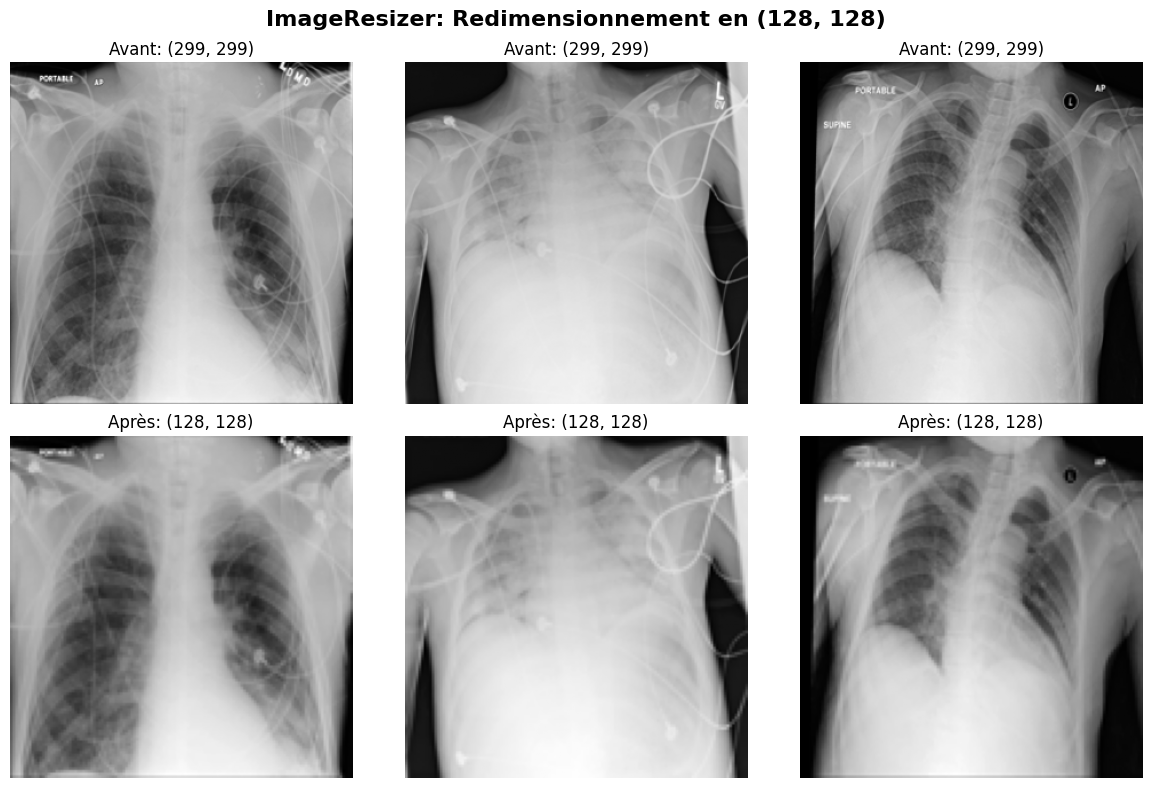

In [25]:
# Exemple de visualisation: ImageResizer
print("="*60)
print("VISUALISATION: ImageResizer")
print("="*60)

# Charger quelques images (limité pour la démo)
sample_loader = ImagePathLoader(root_dir=root_dir)
image_paths, mask_paths, labels = sample_loader.fit_transform(None)

# Prendre seulement 30 images et créer le DataFrame
sample_df = pd.DataFrame({
    'image_path': image_paths[:30],
    'mask_path': mask_paths[:30],
    'label': labels[:30]
})

# Charger les images en mémoire
analyzer = ImageAnalyser(load_images=True)
sample_with_images = analyzer.fit_transform(sample_df)

# Redimensionner
resizer = ImageResizer(img_size=(128, 128))
sample_resized = resizer.fit_transform(sample_with_images)

# Visualiser
resizer.visualize(sample_with_images, sample_resized, n_samples=3)


VISUALISATION: ImageAugmenter
[INFO] [ImageAugmenter] Augmentation de 3 images (p=1.0) (DataFrame)


[ImageAugmenter] Augmentation: 100%|██████████| 3/3 [00:00<00:00, 453.36it/s]

[INFO] [ImageAugmenter] Augmentation terminée: 3/3 images augmentées


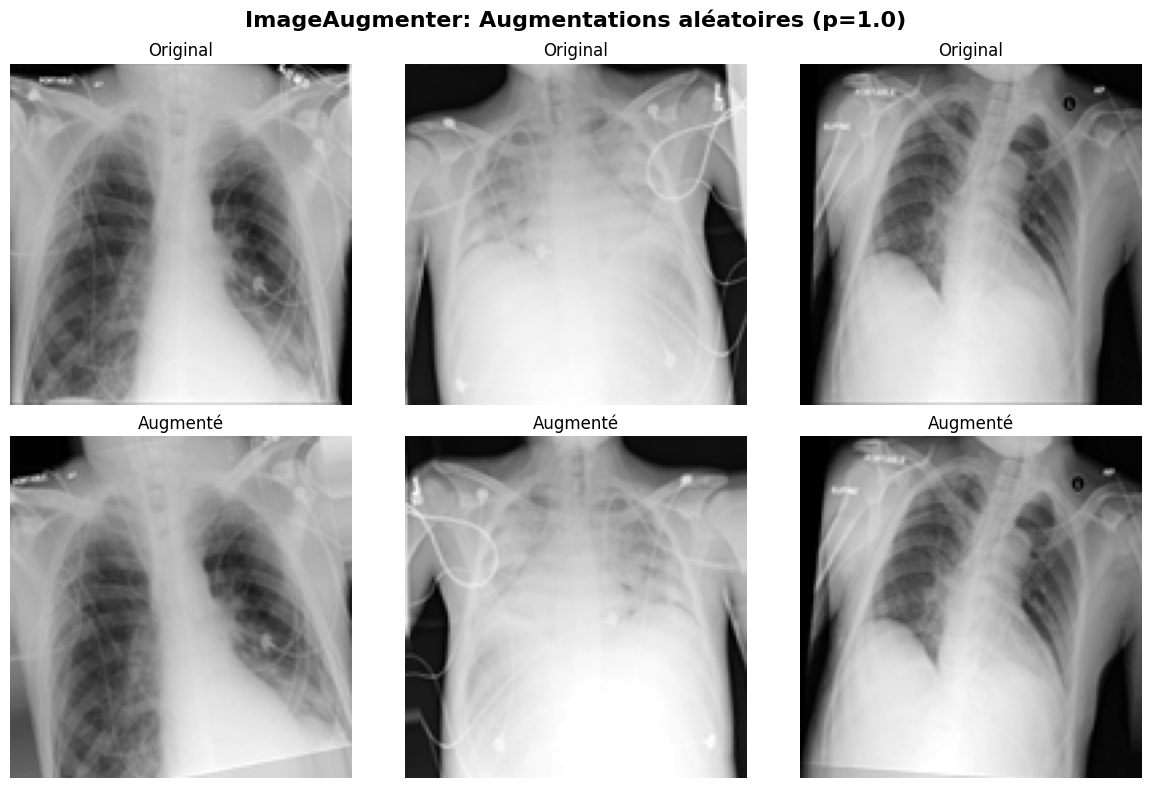


📊 Statistiques d'augmentation:
   - Probabilité: 1.0
   - Rotation max: ±15°
   - Images augmentées: 3/3


In [26]:
# Exemple 2: ImageAugmenter
print("\n" + "="*60)
print("VISUALISATION: ImageAugmenter")
print("="*60)

augmenter = ImageAugmenter(
    flip_horizontal=True,
    rotation_range=15,
    brightness_range=(0.8, 1.2),
    probability=1.0,  # 100% pour voir toutes les augmentations
    seed=42
)
sample_augmented = augmenter.fit_transform(sample_resized.head(3).copy())
augmenter.visualize(sample_resized.head(3), sample_augmented, n_samples=3)


VISUALISATION: ImageNormalizer
[INFO] [ImageNormalizer] Normalisation de 3 images (DataFrame)


[ImageNormalizer] Normalisation: 100%|██████████| 3/3 [00:00<00:00, 2123.34it/s]



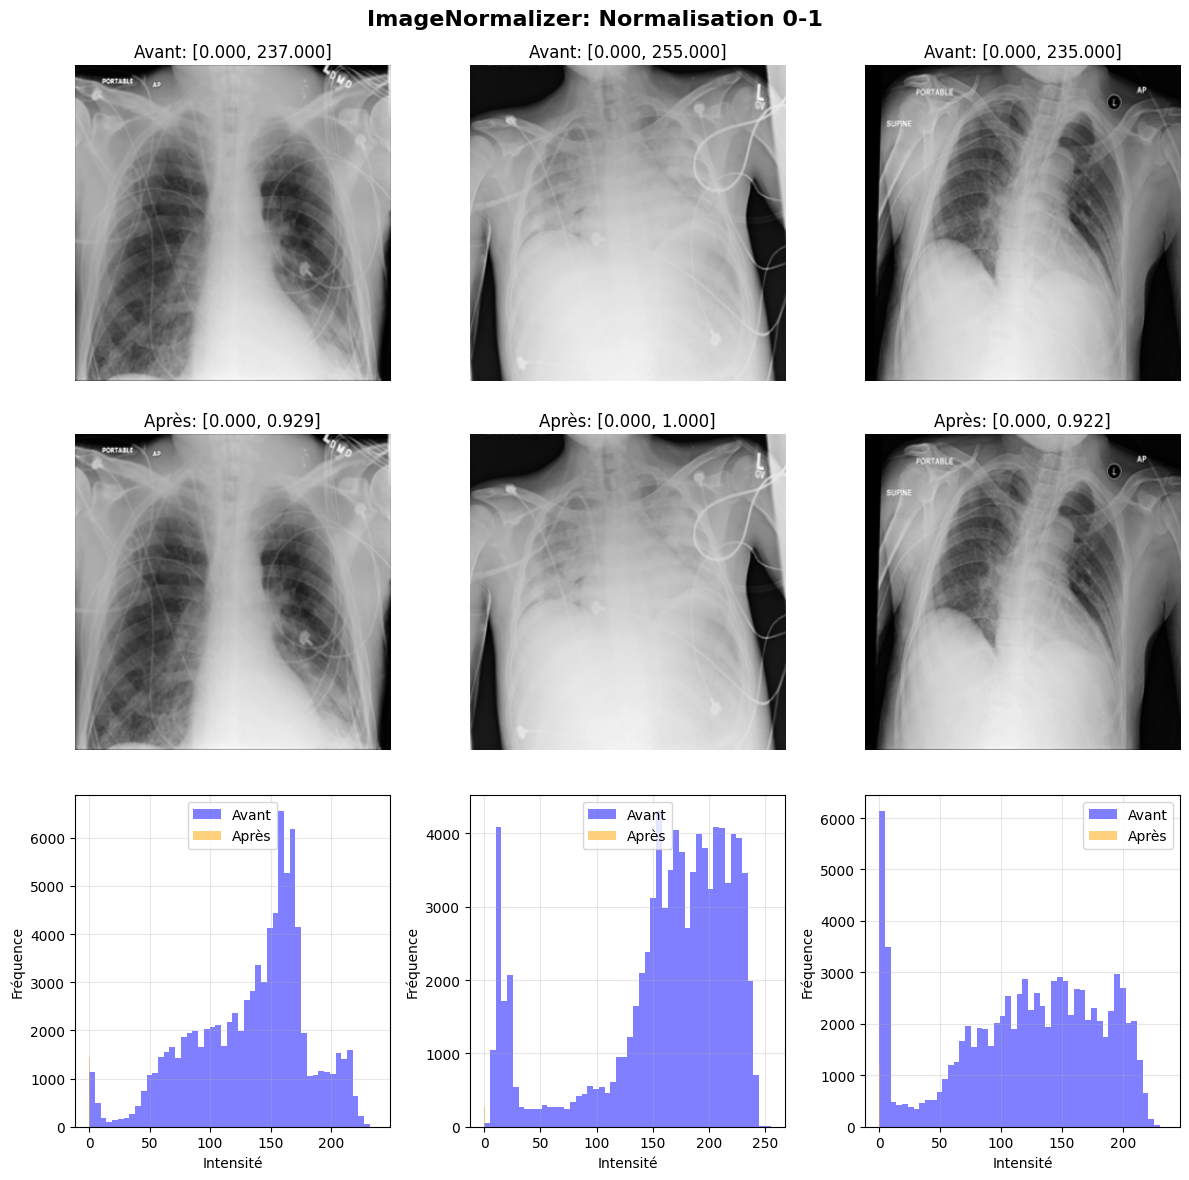

In [27]:
# Exemple 3: ImageNormalizer
print("\n" + "="*60)
print("VISUALISATION: ImageNormalizer")
print("="*60)

normalizer = ImageNormalizer()
sample_normalized = normalizer.fit_transform(sample_with_images.head(3).copy())
normalizer.visualize(sample_with_images.head(3), sample_normalized, n_samples=3)


VISUALISATION: ImageHistogram
[INFO] [ImageHistogram] Calcul des histogrammes (32 bins) pour 3 images


[ImageHistogram] Histogrammes: 100%|██████████| 3/3 [00:00<00:00, 674.72it/s]



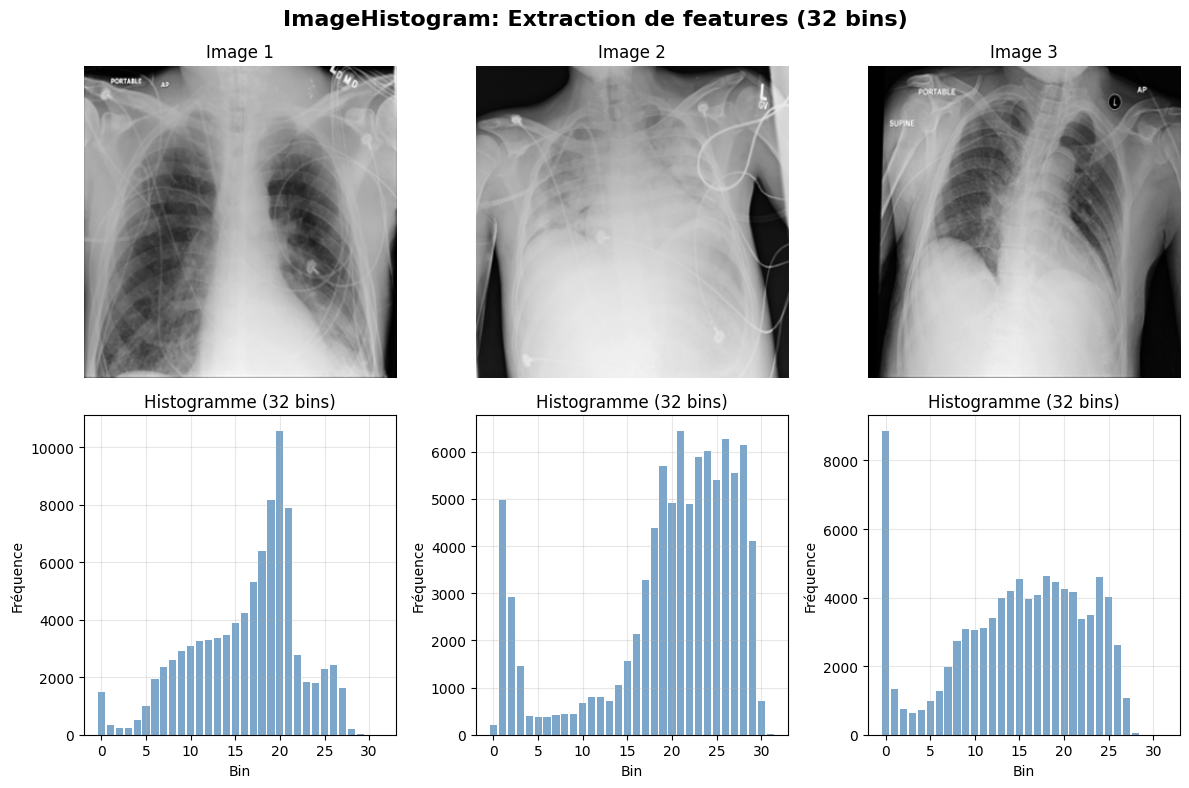


📊 Statistiques histogrammes:
   - Nombre de bins: 32
   - Shape output: (3, 32)
   - Compression: 89401 pixels → 32 features


In [28]:
# Exemple 4: ImageHistogram
print("\n" + "="*60)
print("VISUALISATION: ImageHistogram")
print("="*60)

histogram = ImageHistogram(bins=32)
features_hist = histogram.fit_transform(sample_normalized.head(3))
histogram.visualize(sample_normalized.head(3), features_hist, n_samples=3)


VISUALISATION: ImagePCA
[INFO] [ImageAnalyser] Analyse de 30 images


[ImageAnalyser] Analyse métadonnées: 100%|██████████| 30/30 [00:00<00:00, 7408.69it/s]


[INFO] [ImageAnalyser] Analyse terminée: 1 dimensions uniques
[INFO] [ImageAnalyser] Chargement de 30 images en mémoire


[ImageAnalyser] Chargement images: 100%|██████████| 30/30 [00:00<00:00, 651.14it/s]


[INFO] [ImageAnalyser] Chargement terminé: 30 images chargées
[INFO] [ImageResizer] Redimensionnement de 30 images en (128, 128) (DataFrame)


...

[ImageNormalizer] Normalisation: 100%|██████████| 30/30 [00:00<00:00, 10450.06it/s]


[INFO] [ImageFlattener] Aplatissement de 30 images (DataFrame)


[ImageFlattener] Aplatissement: 100%|██████████| 30/30 [00:00<00:00, 11699.59it/s]

[INFO] [ImagePCA] Apprentissage PCA avec 20 composantes sur (30, 16384)


[INFO] [ImagePCA] PCA fitted. Variance expliquée: 95.58%
[INFO] [ImagePCA] Application PCA sur (30, 16384)
[INFO] [ImagePCA] PCA terminé. Shape: (30, 20)


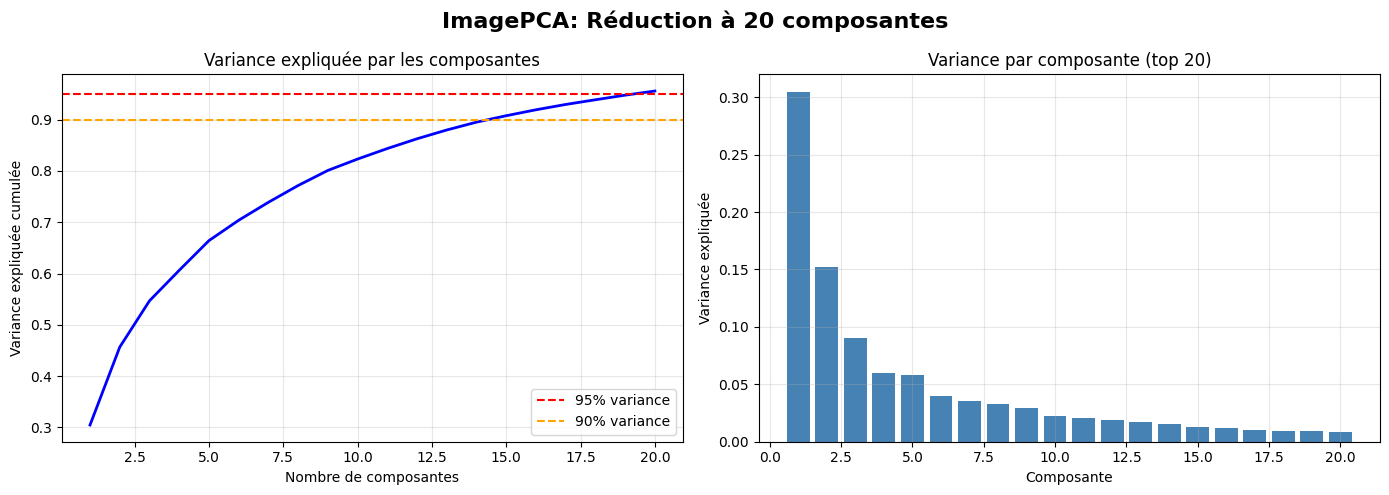


📊 Statistiques PCA:
   - Dimensions avant: (30, 7)
   - Dimensions après: (30, 20)
   - Variance totale expliquée: 95.58%
   - Compression: 285.71% (7 → 20 features)


In [30]:
# Exemple 5: ImagePCA
print("\n" + "="*60)
print("VISUALISATION: ImagePCA")
print("="*60)

# Utiliser les données déjà chargées et en prendre plus
# Charger plus d'images pour le PCA (meilleure analyse de variance)
analyzer_pca = ImageAnalyser(load_images=True)
sample_for_pca = analyzer_pca.fit_transform(sample_df.head(30))

resizer_pca = ImageResizer(img_size=(128, 128))
sample_resized_pca = resizer_pca.fit_transform(sample_for_pca)

normalizer_pca = ImageNormalizer()
sample_normalized_pca = normalizer_pca.fit_transform(sample_resized_pca)

# D'abord flatten les images
flattener = ImageFlattener()
sample_flat = flattener.fit_transform(sample_normalized_pca)

# Puis PCA (max 30 composantes car seulement 30 échantillons)
pca = ImagePCA(n_components=20)
pca.fit(sample_flat)  # Fit séparément pour s'assurer que pca.pca est initialisé
features_pca = pca.transform(sample_flat)
pca.visualize(sample_flat, features_pca, n_samples=3)

### 📊 Résumé des visualisations

Chaque transformateur dispose de sa méthode `visualize()` qui génère des plots appropriés :

**ImageResizer** 
- Comparaison avant/après redimensionnement
- Affichage des dimensions

**ImageAugmenter**
- Visualisation des augmentations aléatoires
- Statistiques d'augmentation (probabilité, rotation, nb d'images augmentées)

**ImageNormalizer**
- Images avant/après normalisation
- Histogrammes de distribution des intensités
- Plages de valeurs [min, max]

**ImageHistogram**
- Images originales
- Histogrammes extraits (features)
- Statistiques de compression

**ImagePCA**
- Variance expliquée cumulée
- Variance par composante (top 20)
- Statistiques de réduction dimensionnelle

💡 **Usage dans Streamlit** : Ces visualisations sont automatiquement adaptées pour l'affichage dans Streamlit en utilisant `st.pyplot()` au lieu de `plt.show()`.